# Report

Questo notebook verrà utilizzato per mostrare passo passo l'analisi fatta a partire dai dati grezzi fino alla creazione dei modelli di forecasting e la valutazione di essi.

## Approccio utilizzato

> 1. Descriptive analysis
> 2. Preprocessing
> 3. Modelli statistici baseline
> 4. Modelli ML non neurali
> 5. Modelli neurali
> 6. Confronto prestazionale
> 7. Inferential statistics sui confronti
> 8. Prescriptive analytics 

NB_Gli step 3-4-5 comprenderanno anche la parte di parameter fitting.


## 1. Analisi descrittiva (step by step)

In questa sezione riportiamo, nello stesso ordine del codice Python, metriche e grafici già generati in Results/ per la serie consumo totale.

### 1.0 Caricamento dei risultati


In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Risoluzione robusta della root progetto
project_root = Path.cwd()
if not (project_root / "Results").exists() and (project_root.parent / "Results").exists():
    project_root = project_root.parent

metrics_dir = project_root / "Results" / "metrics"
plots_dir = project_root / "Results" / "plots" / "descriptive"

# Caricamento metriche generate dallo script principale
series_df = pd.read_csv(metrics_dir / "tavola_1_14_series_clean_v1.csv")
freq_df = pd.read_csv(metrics_dir / "tavola_1_14_frequency_distribution_v1.csv")
central_df = pd.read_csv(metrics_dir / "tavola_1_14_central_tendency_v1.csv")
dispersion_df = pd.read_csv(metrics_dir / "tavola_1_14_dispersion_measures_v1.csv")
outliers_df = pd.read_csv(metrics_dir / "tavola_1_14_outliers_iqr_v1.csv")
outlier_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_outliers_summary_v1.csv")

print(f"Project root: {project_root}")
print(f"Rows in cleaned series: {len(series_df)}")

Project root: c:\Users\giann\Documents\GitHub\FinalProject
Rows in cleaned series: 83


### 1.1 Serie base

Visualizzazione della serie annuale dei consumi (1931 in avanti) per capirne l'andamento con un primo approccio visivo.

,year,consumo_totale
0,1931,8335.0
1,1932,8420.0
2,1933,9293.0
3,1934,10159.0
4,1935,11168.0
5,1936,11588.0
6,1937,13160.0
7,1938,13339.0
8,1939,15806.0
9,1940,16674.0


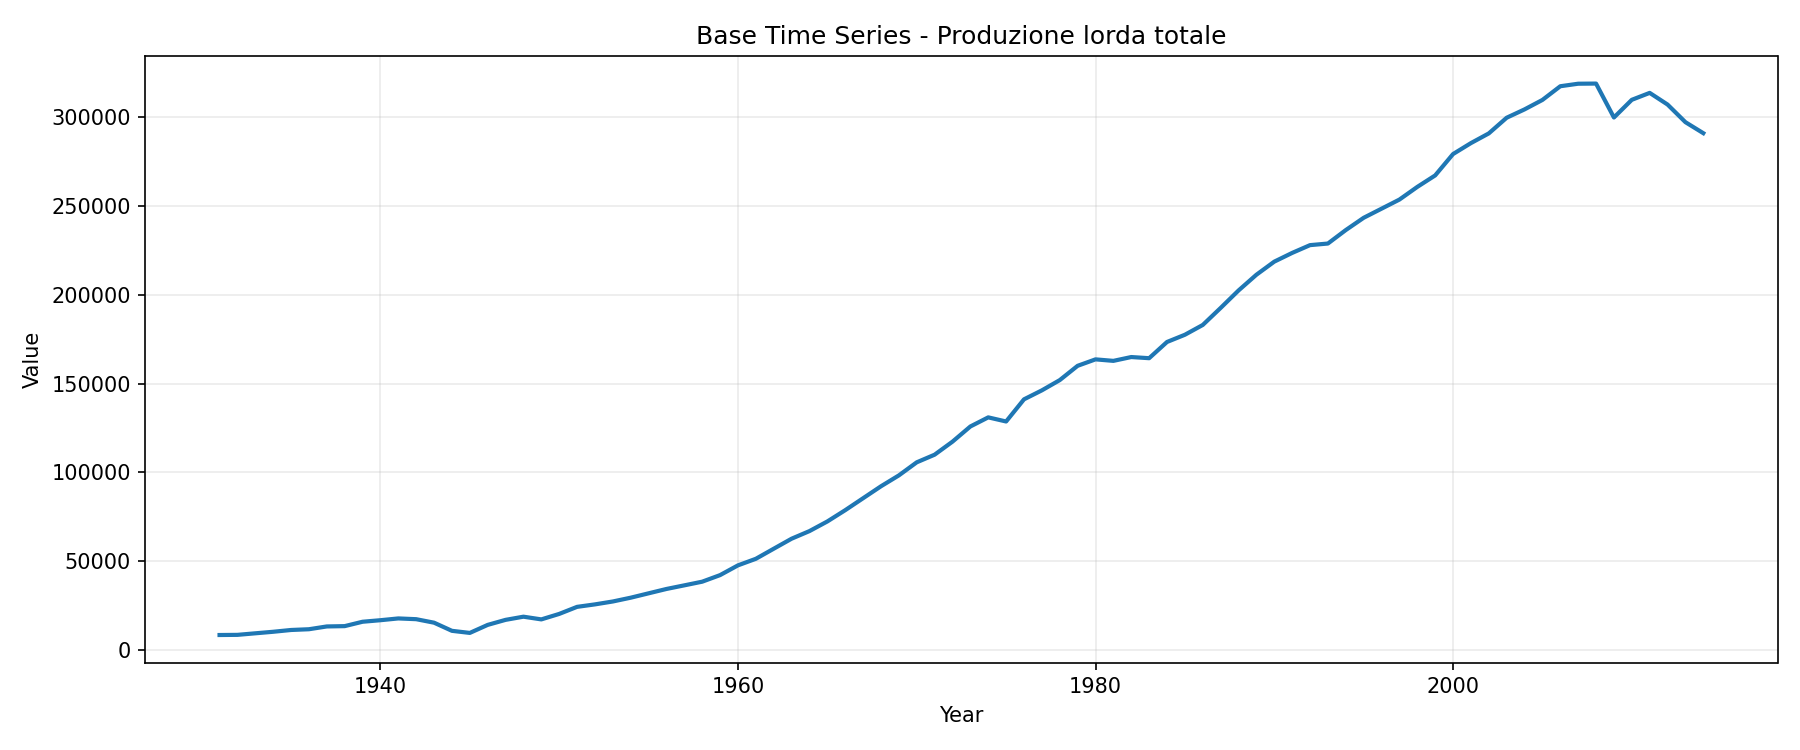

In [10]:
display(series_df.head(10))
display(Image(filename=str(plots_dir / "tavola_1_14_series_base_v1.png")))

### 1.2 Frequency distribution (empirica, relativa, bar chart)

La tabella seguente contiene le classi con frequenza assoluta e relativa.

,class_interval,absolute_frequency,relative_frequency
0,"(8024.297, 47172.75]",29,0.349398
1,"(47172.75, 86010.5]",8,0.096386
2,"(86010.5, 124848.25]",5,0.060241
3,"(124848.25, 163686.0]",9,0.108434
4,"(163686.0, 202523.75]",7,0.084337
5,"(202523.75, 241361.5]",6,0.072289
6,"(241361.5, 280199.25]",5,0.060241
7,"(280199.25, 319037.0]",14,0.168675


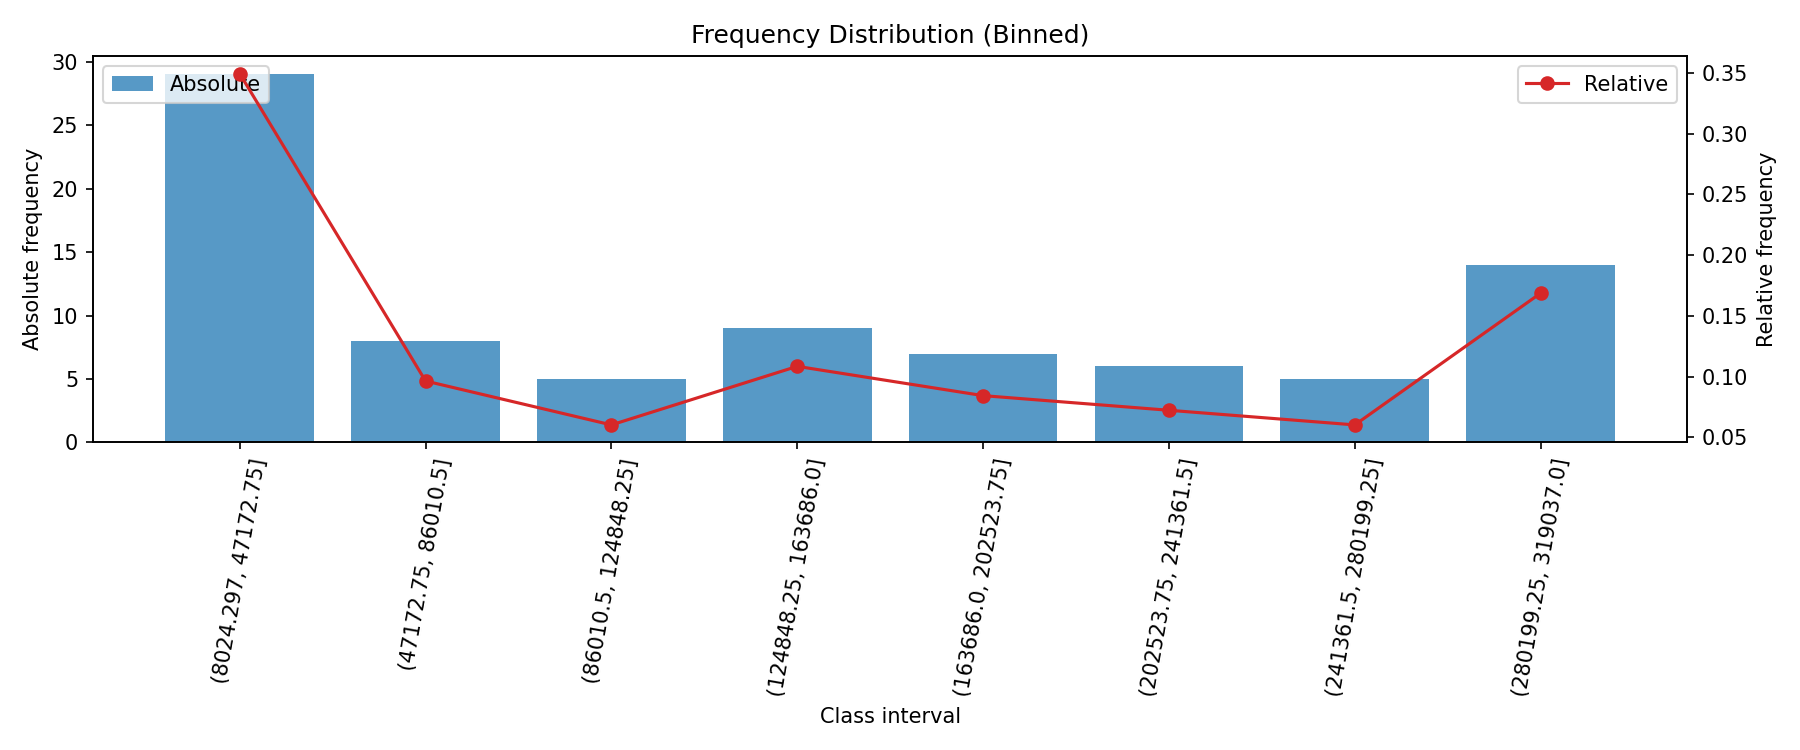

In [11]:
display(freq_df)
display(Image(filename=str(plots_dir / "tavola_1_14_frequency_distribution_v1.png")))

### 1.3 Central tendency e dispersion measures

Qui riportiamo media, mediana, moda, e poi range, varianza, deviazione standard, coefficiente di variazione e IQR.

In [12]:
display(central_df)
display(dispersion_df)

,mean,median,mode
0,133683.915663,117279.0,8335.0


,range,variance,std_dev,coefficient_of_variation,iqr
0,310702.0,1.202190e+10,109644.402502,0.820176,203562.0


### 1.4 Outliers globali e studio della distribuzione

Outlier globali identificati con regola IQR sui livelli della serie. Per confronto coerente usiamo il boxplot sui livelli; in aggiunta mostriamo densita empirica vs fit normale/uniforme, distribuzione discreta e Q-Q plot.

,lower_fence,upper_fence,num_outliers,outlier_ratio
0,-280448.0,533800.0,0,0.0


,year,value


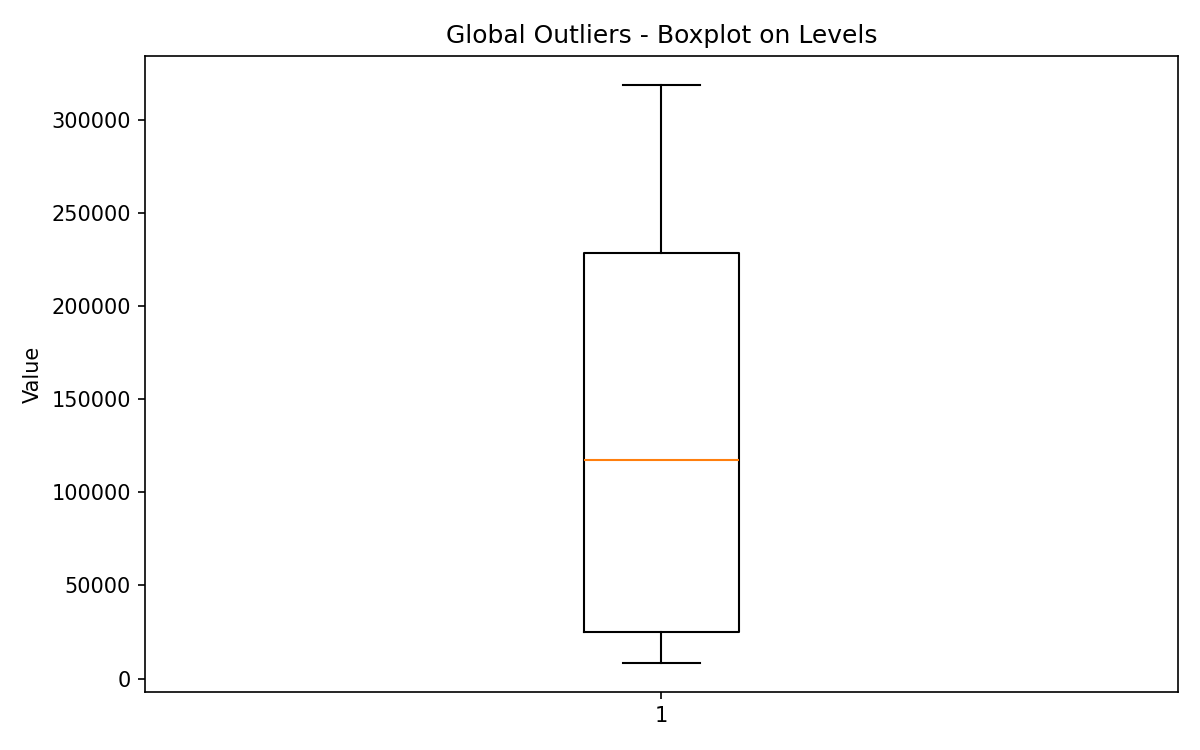

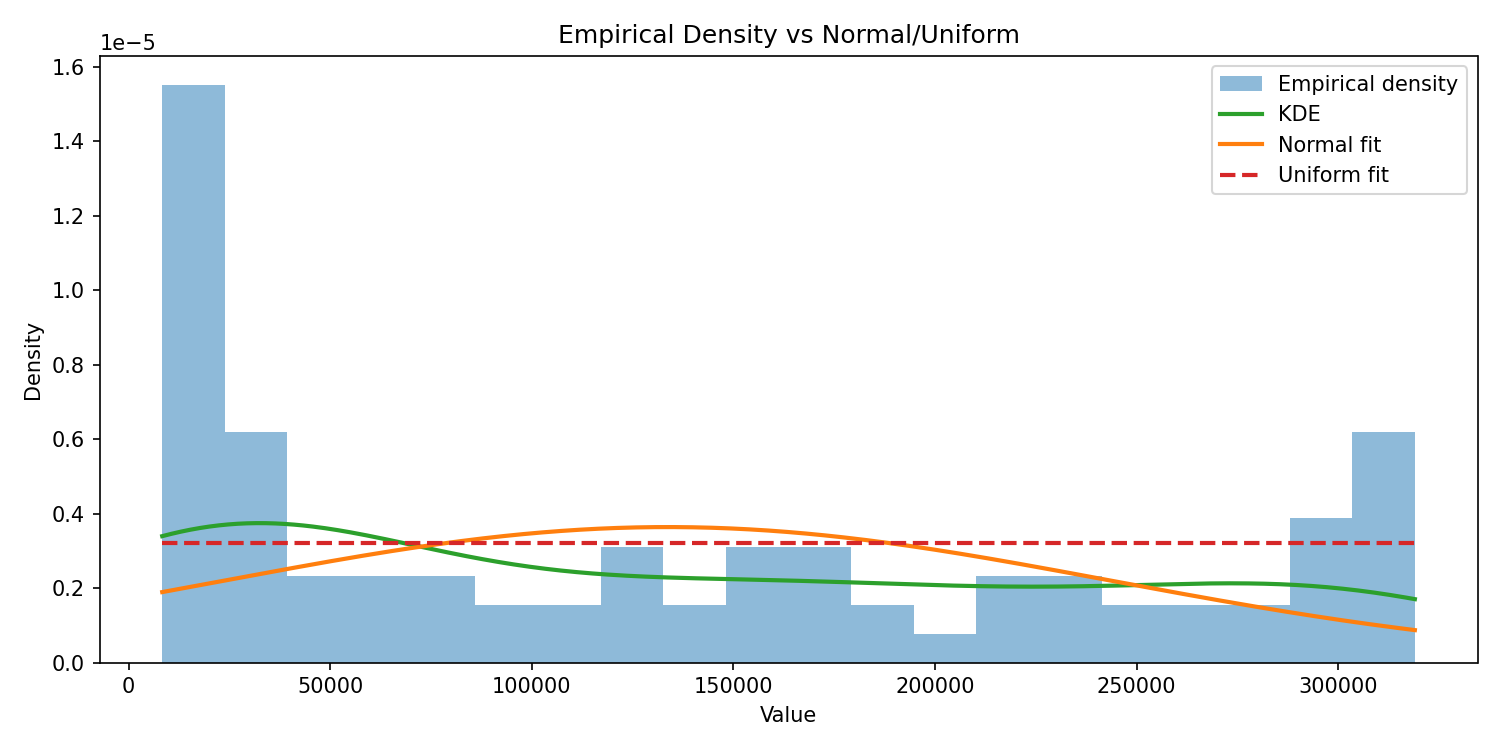

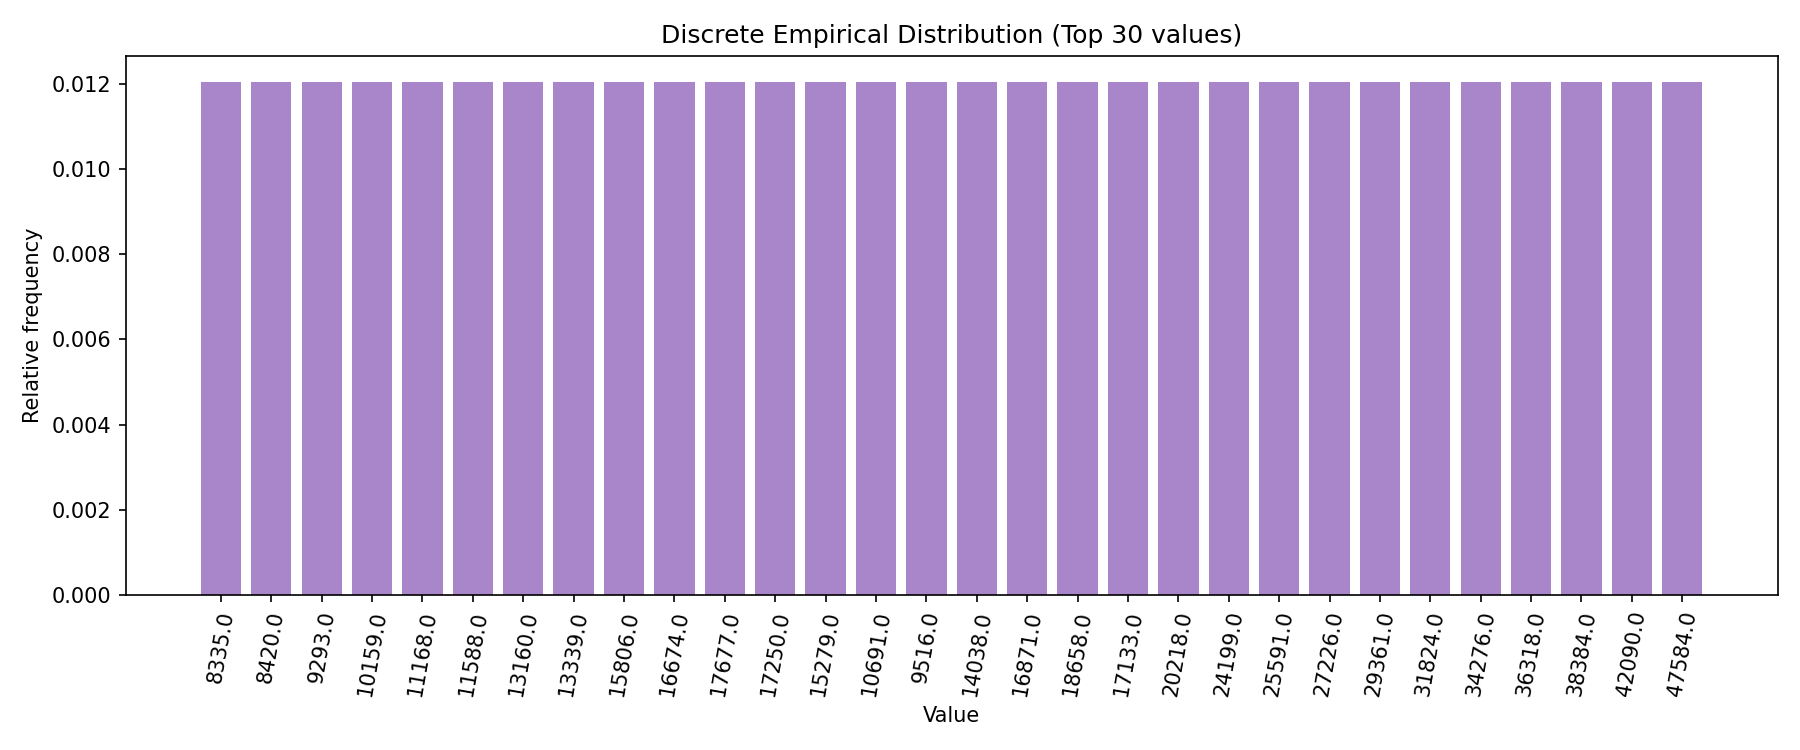

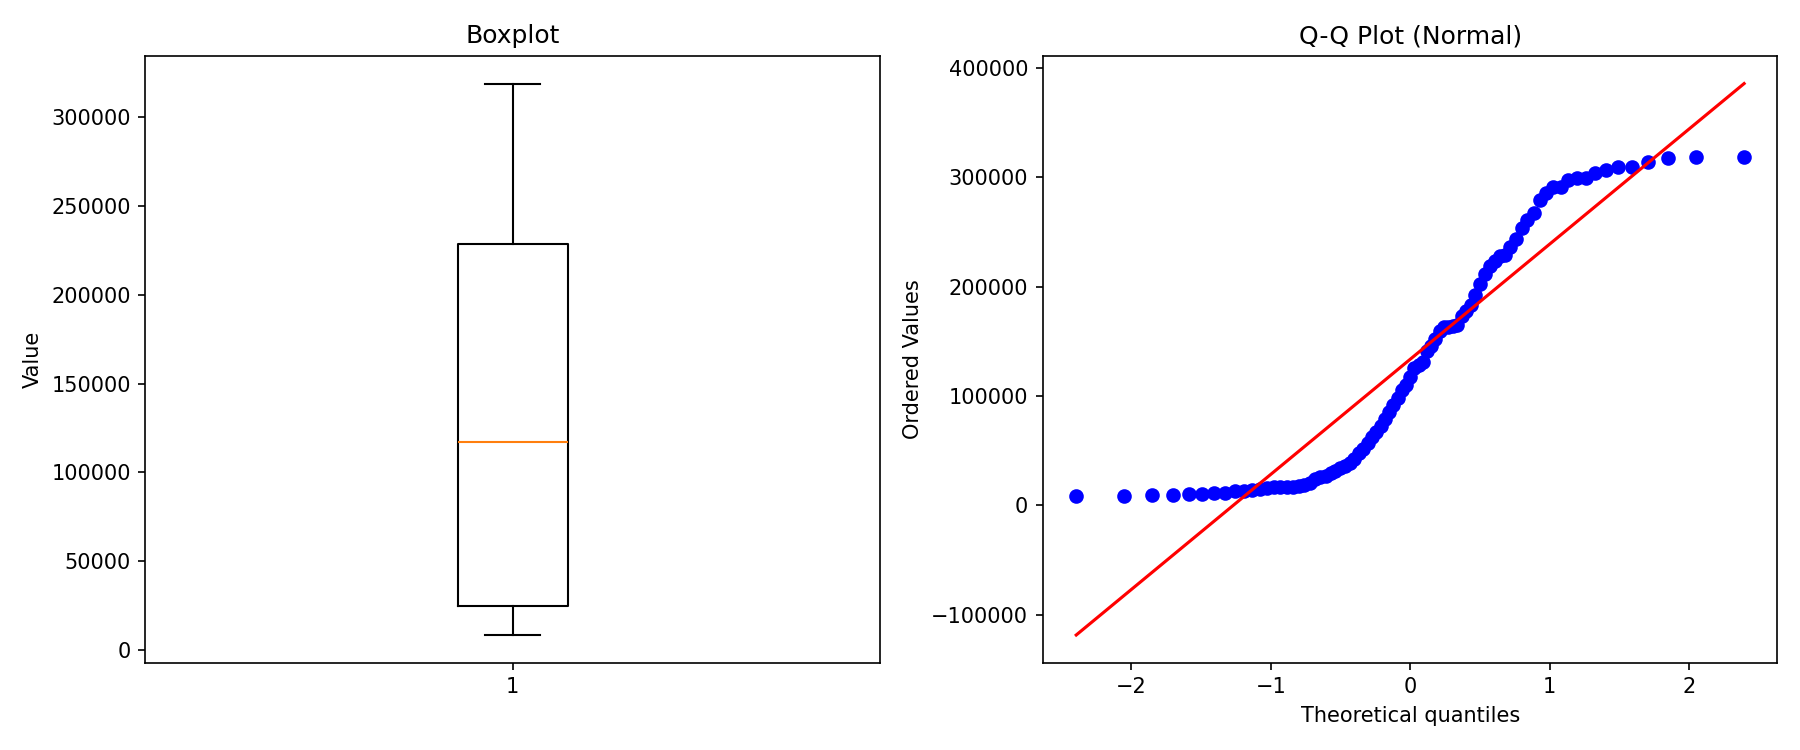

In [13]:
display(outlier_summary_df)
display(outliers_df.head(20))

# Stessa tipologia grafica usata anche per gli outlier locali (sezione 1.5)
display(Image(filename=str(plots_dir / "tavola_1_14_global_outliers_boxplot_v1.png")))

display(Image(filename=str(plots_dir / "tavola_1_14_density_comparison_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_discrete_distribution_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_outliers_qqplot_v1.png")))

### 1.5 Validazione numerica di trend crescente e anomalie locali

Per evitare che il trend globale nasconda variazioni anomale locali, analizziamo:

- trend lineare e correlazione con il tempo;
- variazioni anno su anno (YoY);
- outlier locali su YoY con baseline mobile (rolling median).

Per confronto omogeneo con la sezione 1.4, usiamo anche qui un boxplot (sulle variazioni YoY).

,n_observations,start_year,end_year,slope_per_year,slope_p_value,r_squared,spearman_rho,spearman_p_value,positive_yoy_share,negative_yoy_share,zero_yoy_share,intercept,slope_std_err
0,83,1931,2014,4388.996569,5.730592e-56,0.954104,0.992465,1.252026e-75,0.853659,0.146341,0.0,-8.522369e+06,106.957792


,window,threshold,n_yoy_points,num_local_outliers,local_outlier_ratio,yoy_mean,yoy_std,yoy_q05,yoy_q95
0,11,3.5,82,4,0.04878,3448.158537,4824.903457,-4474.75,9820.0


,year,yoy_change,local_median_change,residual_vs_local,rolling_mad,local_score,is_local_outlier
0,1960,5494.0,3706.0,1788.0,250.0,4.824024,True
1,1975,-2323.0,5770.0,-8093.0,1011.0,-5.399336,True
2,2000,12036.0,6911.0,5125.0,739.0,4.677689,True
3,2009,-19122.0,1420.0,-20542.0,3512.0,-3.945210,True


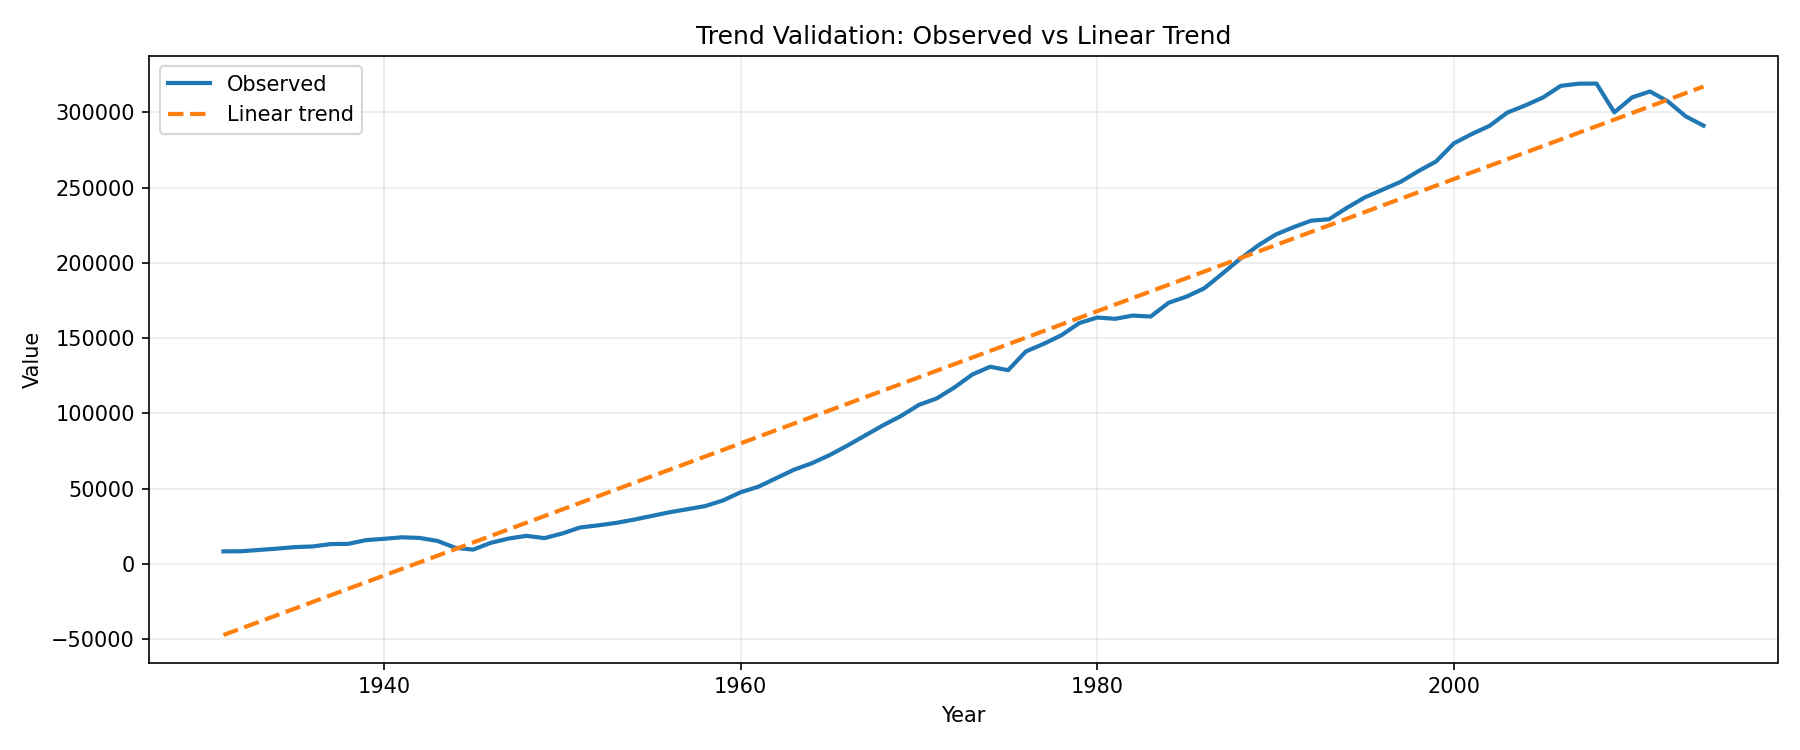

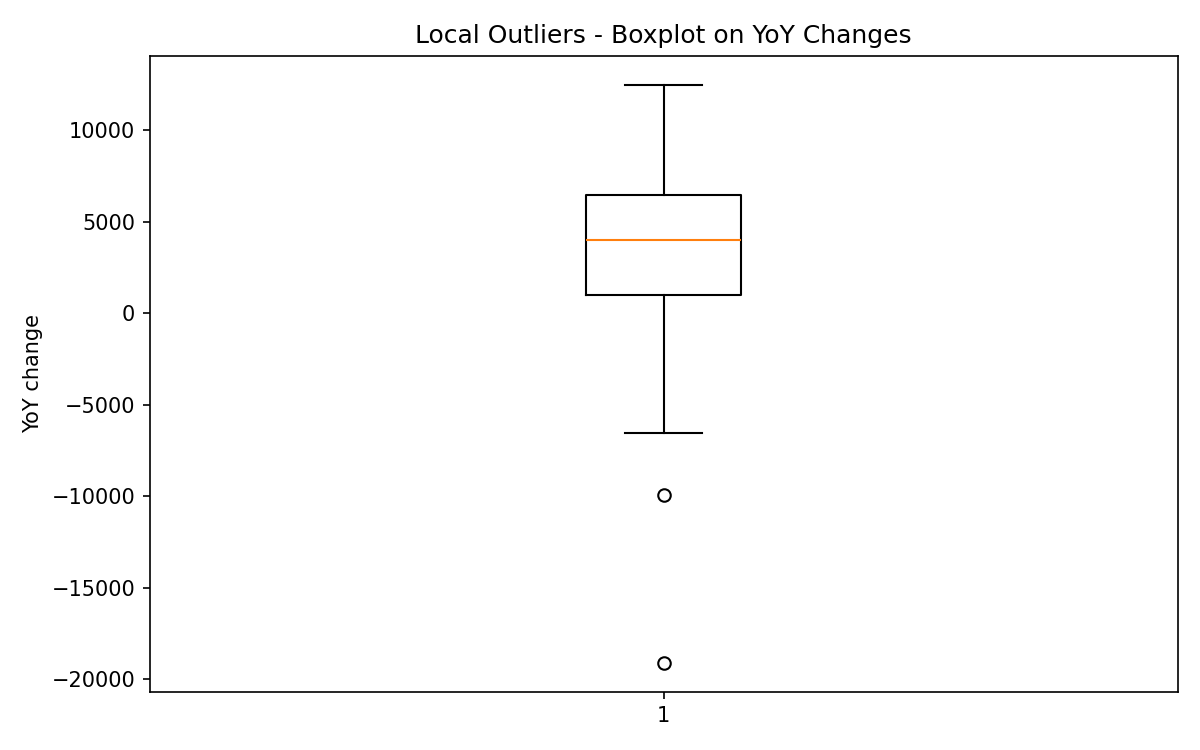

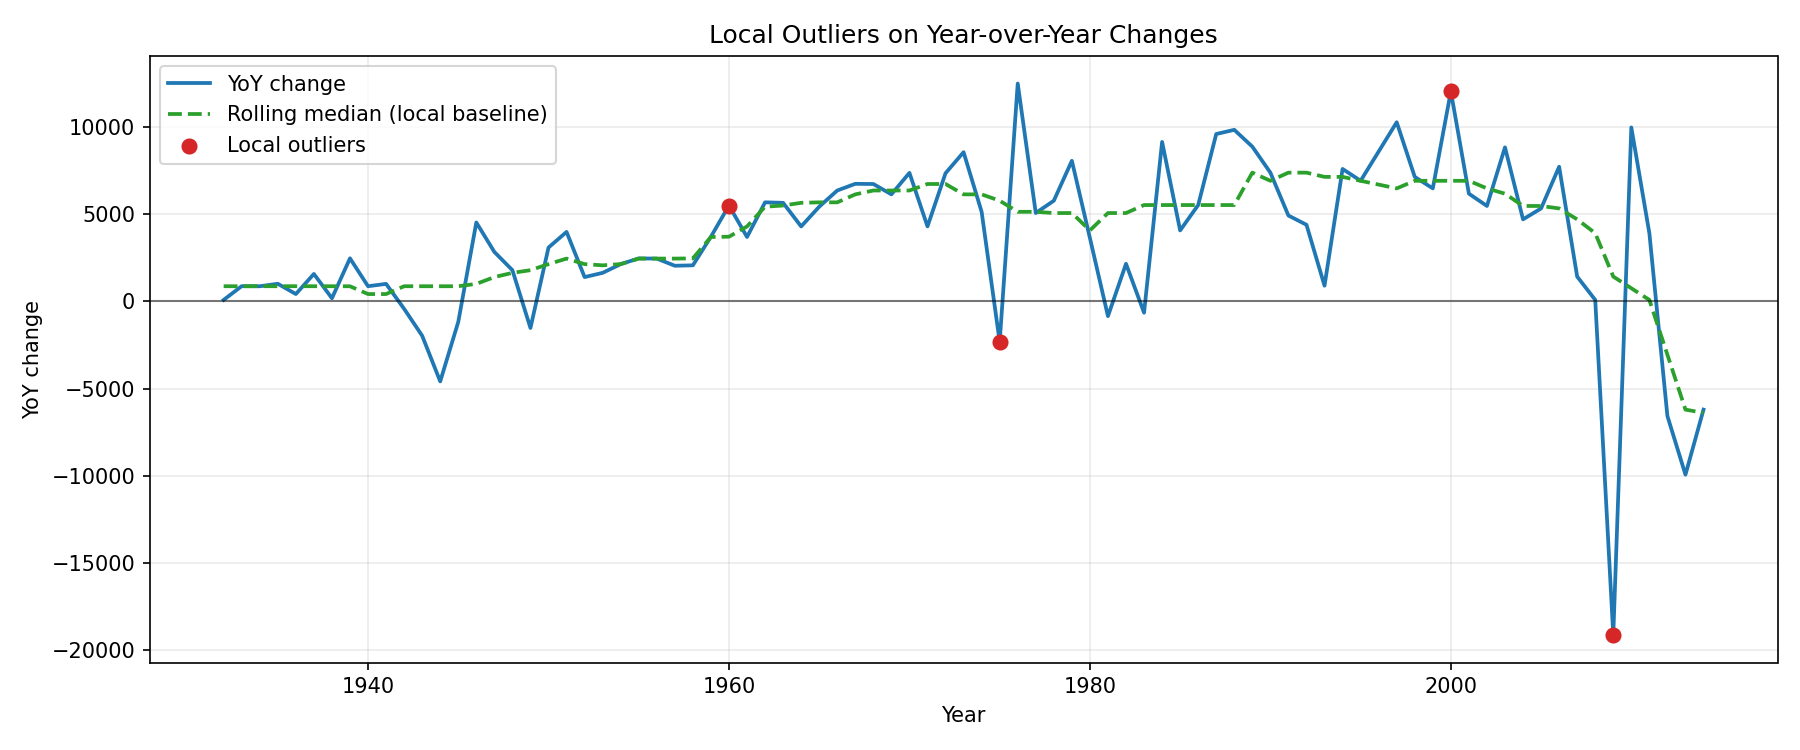

In [14]:
trend_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_trend_summary_v1.csv")
local_outliers_summary_df = pd.read_csv(metrics_dir / "tavola_1_14_local_outliers_summary_v1.csv")
local_outliers_df = pd.read_csv(metrics_dir / "tavola_1_14_local_outliers_yoy_v1.csv")

display(trend_summary_df)
display(local_outliers_summary_df)
display(local_outliers_df)

display(Image(filename=str(plots_dir / "tavola_1_14_trend_validation_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_local_outliers_boxplot_v1.png")))
display(Image(filename=str(plots_dir / "tavola_1_14_local_outliers_yoy_v1.png")))

### 1.6 Confronto tra analisi globale e locale

Il confronto tra le due analisi mostra che non ci sono outlier globali sui livelli (IQR), ma emergono poche anomalie locali quando si osservano le variazioni anno-su-anno rispetto a una baseline mobile. Questo risultato e coerente con una serie a trend crescente: i valori elevati negli anni recenti non sono necessariamente anomali in senso assoluto, mentre alcuni salti o crolli puntuali rappresentano shock locali. Di conseguenza, nella fase di preprocessing e preferibile trattare queste osservazioni come eventi specifici della dinamica temporale, evitando rimozioni automatiche basate solo su soglie globali.

## 2. Preprocessing

In questa sezione applichiamo il preprocessing tenendo conto delle conclusioni della fase descrittiva: trend forte, assenza di outlier globali e presenza di pochi shock locali.

Checklist operativa adottata:

1. split temporale train/validation/test senza leakage;
2. trasformazioni candidate (nessuna, diff1, log1p+diff1, log1p+diff2);
3. test di stazionarieta su train (ADF + KPSS, Shapiro opzionale);
4. rilevazione outlier locali su variazioni YoY (rolling baseline);
5. scelta configurazione finale per lo Step 3.

Criterio decisionale per stazionarieta (train):
- ADF: p-value < 0.05
- KPSS: p-value >= 0.05

### 2.0 Setup e artefatti

Carichiamo metriche e grafici generati dallo script, insieme alla configurazione finale selezionata automaticamente nello Step 2 (`tavola_1_14_preproc_selected_config_v1.json`).

In [34]:
import json

preproc_metrics_dir = project_root / "Results" / "metrics"
preproc_plots_dir = project_root / "Results" / "plots" / "preprocessing"
preproc_artifacts_dir = project_root / "Results" / "artifacts"

preproc_split_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_split_summary_v1.csv")
preproc_tests_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_tests_v1.csv")
preproc_candidates_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_candidate_tests_v1.csv")
preproc_local_outliers_df = pd.read_csv(preproc_metrics_dir / "tavola_1_14_preproc_local_outliers_v1.csv")

selected_cfg_path = preproc_artifacts_dir / "tavola_1_14_preproc_selected_config_v1.json"
with open(selected_cfg_path, "r", encoding="utf-8") as f:
    preproc_selected_cfg = json.load(f)

selected_transform = preproc_selected_cfg["transform"]
selected_use_log1p = bool(selected_transform.get("use_log1p", False))
selected_diff_order = int(selected_transform.get("diff_order", 0))
selected_scale_method = str(selected_transform.get("scale_method", "none"))

selected_transform_label = (
    ("log1p + " if selected_use_log1p else "")
    + (f"diff{selected_diff_order}" if selected_diff_order > 0 else "no diff")
)

preproc_candidates_ranked = preproc_candidates_df.sort_values(
    ["adf_stationary_train", "kpss_stationary_train", "kpss_pvalue_train", "diff_order", "adf_pvalue_train"],
    ascending=[False, False, False, True, True],
)
best_stationary = preproc_candidates_ranked[
    (preproc_candidates_ranked["adf_stationary_train"] == True)
    & (preproc_candidates_ranked["kpss_stationary_train"] == True)
]

best_cfg_row = (
    best_stationary.head(1) if len(best_stationary) > 0 else preproc_candidates_ranked.head(1)
).iloc[0]

print(f"Selected preprocessing config (artifact): {selected_cfg_path.name}")
print(
    f"Transform={selected_transform_label}, scale={selected_scale_method}, "
    f"split=({preproc_selected_cfg['split']['train_ratio']:.2f}, {preproc_selected_cfg['split']['val_ratio']:.2f}, "
    f"{1 - preproc_selected_cfg['split']['train_ratio'] - preproc_selected_cfg['split']['val_ratio']:.2f})"
)

Selected preprocessing config (artifact): tavola_1_14_preproc_selected_config_v1.json
Transform=log1p + diff1, scale=none, split=(0.70, 0.15, 0.15)


### 2.1 Split temporale

Lo split viene fatto in ordine cronologico, senza shuffle, per evitare leakage tra passato e futuro.

,split,start,end,n
0,train,1932,1988,57
1,val,1989,2001,12
2,test,2002,2014,13


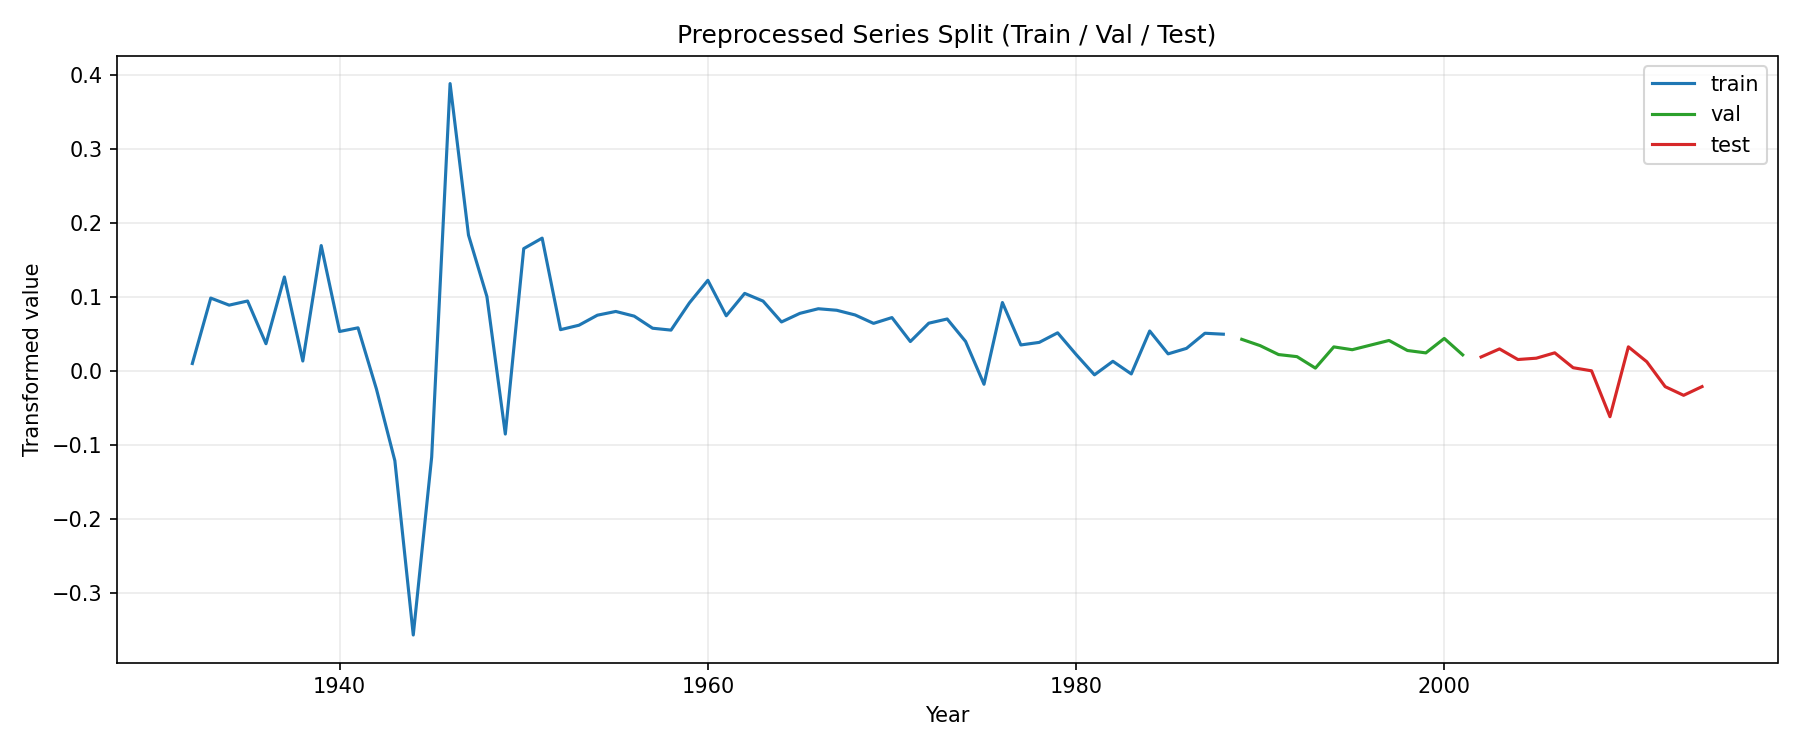

In [16]:
display(preproc_split_df)
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_split_view_v1.png")))

### 2.2 Trasformazioni candidate e scelta finale

Confrontiamo le configurazioni candidate usando i test sul train (diagnostica), ma la scelta finale operativa viene letta dall'artifact JSON generato automaticamente dallo Step 2.

,use_log1p,power_exponent,diff_order,scale_method,adf_pvalue_train,kpss_pvalue_train,adf_stationary_train,kpss_stationary_train
3,True,NaN,2,none,4.243233e-07,0.10,True,True
2,True,NaN,1,none,4.989483e-07,0.10,True,True
1,False,NaN,1,none,3.861201e-04,0.01,True,False
0,False,NaN,0,none,1.000000e+00,0.01,False,False


,use_log1p,power_exponent,diff_order,scale_method,adf_pvalue_train,kpss_pvalue_train,adf_stationary_train,kpss_stationary_train
3,True,NaN,2,none,4.243233e-07,0.1,True,True


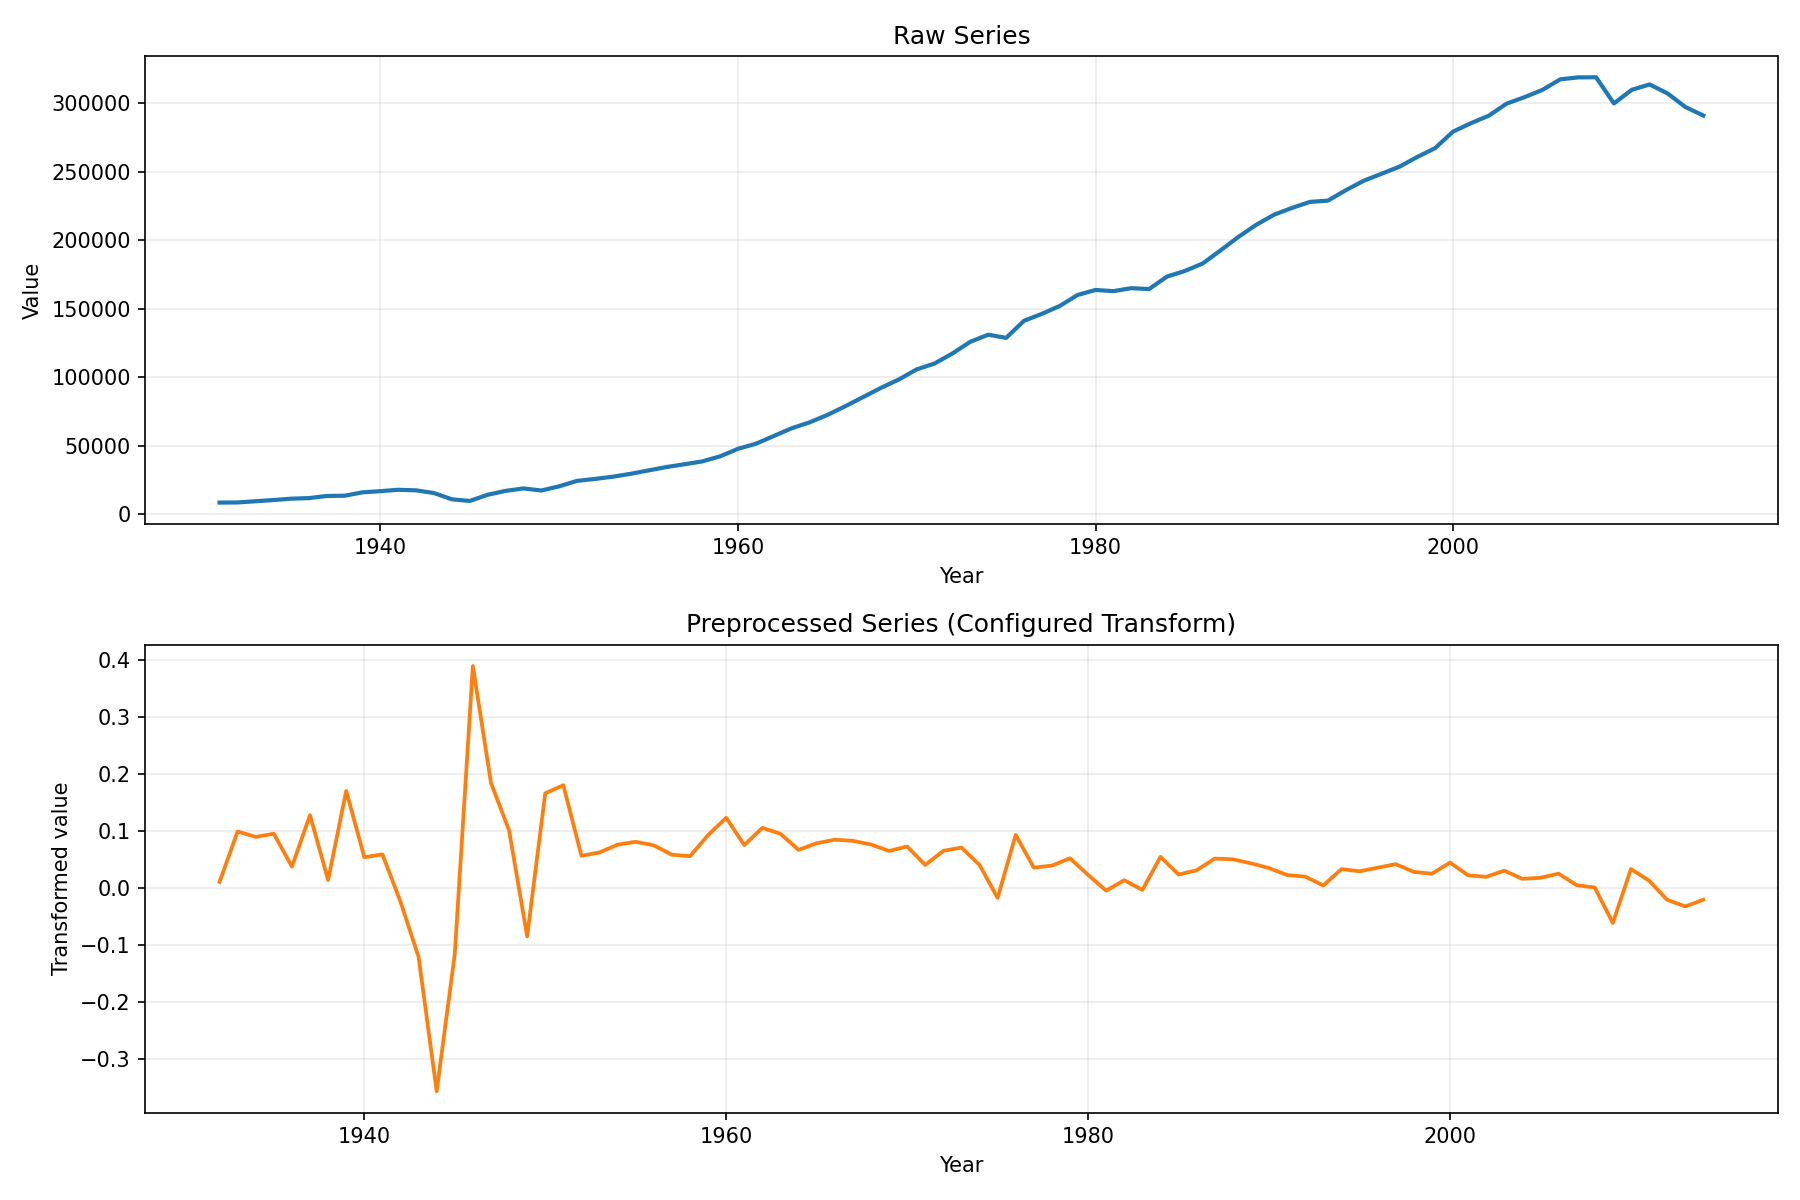

In [17]:
display(preproc_candidates_ranked)
display(best_stationary.head(1) if len(best_stationary) > 0 else preproc_candidates_ranked.head(1))
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_raw_vs_transformed_v1.png")))

### 2.3 Test di stazionarieta

Valutiamo ADF e KPSS su train/validation/test e annotiamo la decisione principale sul train set.

,split,n,adf_stat,adf_pvalue,adf_stationary_at_05,kpss_stat,kpss_pvalue,kpss_stationary_at_05,shapiro_stat,shapiro_pvalue,shapiro_normal_at_05,kpss_note
0,train,57,-5.786332,4.989483e-07,True,0.106045,0.100000,True,0.805962,3.265017e-07,False,The test statistic is outside of the range of ...
1,val,12,-3.049739,3.050333e-02,True,0.109545,0.100000,True,0.945947,5.786885e-01,True,The test statistic is outside of the range of ...
2,test,13,-2.683049,7.701768e-02,False,0.475854,0.047105,False,0.896625,1.202042e-01,True,NaN


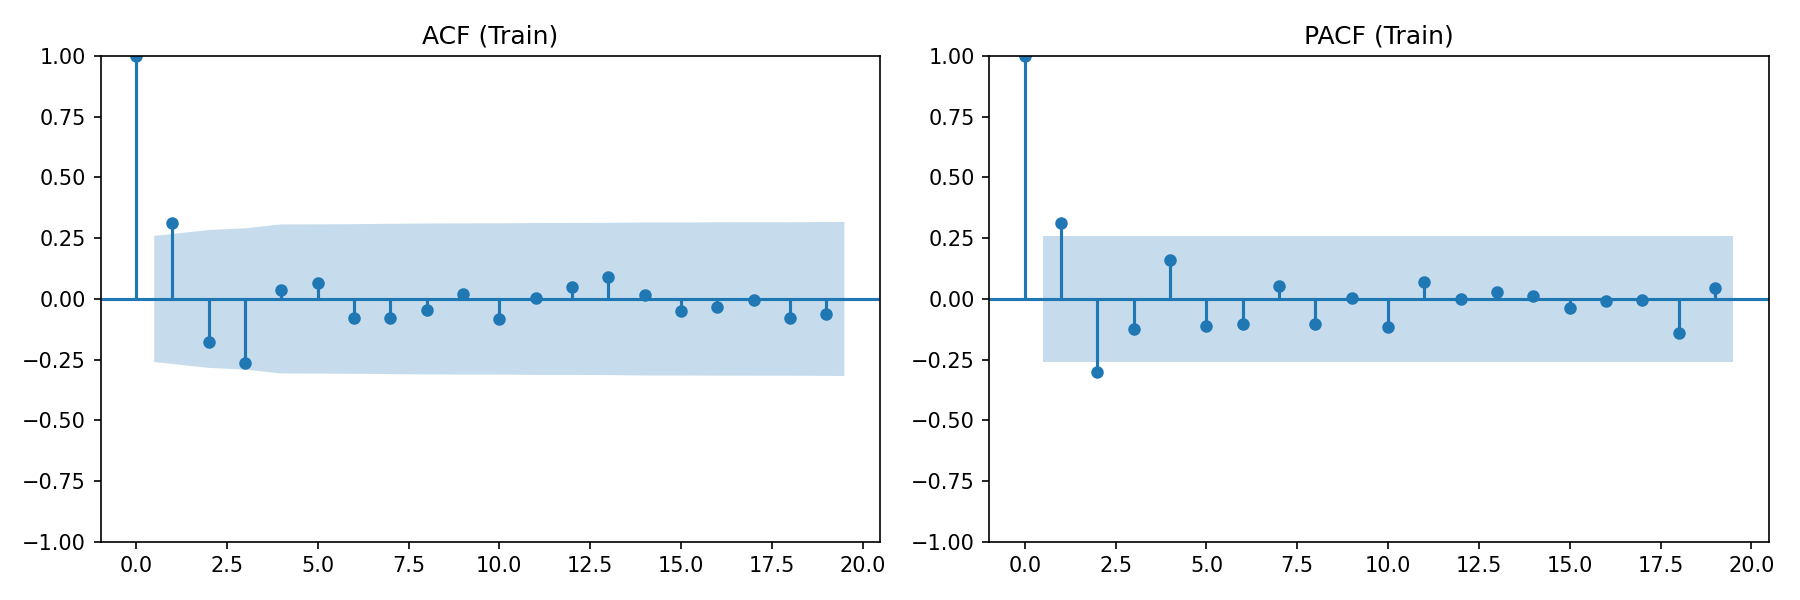

Train - criterio stazionarieta:
ADF p-value = 4.98948e-07 -> OK
KPSS p-value = 0.1 -> OK


In [18]:
display(preproc_tests_df)
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_acf_pacf_v1.png")))

train_tests = preproc_tests_df.loc[preproc_tests_df["split"] == "train"].iloc[0]
print("Train - criterio stazionarieta:")
print(f"ADF p-value = {train_tests['adf_pvalue']:.6g} -> {'OK' if bool(train_tests['adf_stationary_at_05']) else 'NO'}")
print(f"KPSS p-value = {train_tests['kpss_pvalue']:.6g} -> {'OK' if bool(train_tests['kpss_stationary_at_05']) else 'NO'}")

### 2.4 Rilevazione outlier locali su variazioni YoY

Gli outlier locali vengono stimati sulle variazioni anno-su-anno rispetto a una baseline mobile, in coerenza con quanto visto nello Step 1.

,year,yoy_change,rolling_median,rolling_mad,local_score,is_local_outlier
28,1960,5494.0,3706.0,250.0,4.824024,True
43,1975,-2323.0,5770.0,1011.0,-5.399336,True
67,2000,12036.0,6911.0,739.0,4.677689,True
76,2009,-19122.0,1420.0,3512.0,-3.945210,True


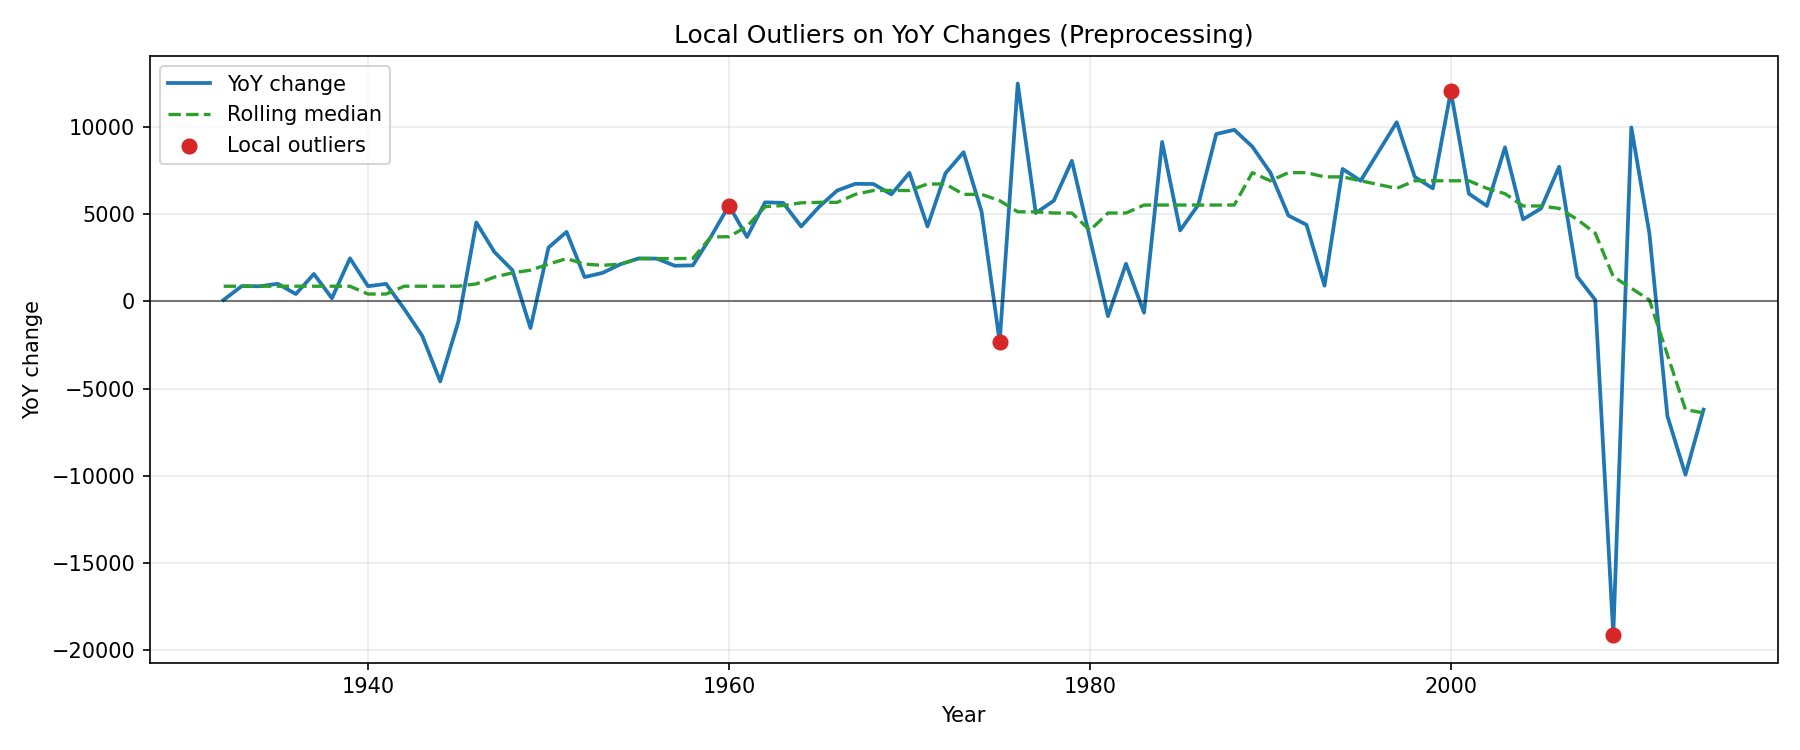

In [19]:
display(preproc_local_outliers_df[preproc_local_outliers_df["is_local_outlier"] == True].head(20))
display(Image(filename=str(preproc_plots_dir / "tavola_1_14_preproc_local_outliers_v1.png")))

### 2.5 Preprocessing Conclusion: Statistical

Configurazione in uso per il modello statistico: letta automaticamente da artifact (`tavola_1_14_preproc_selected_config_v1.json`).
Il criterio resta quello definito nello Step 2 (ADF + KPSS), con tie-break conservativo su differencing.

### 2.6 Preprocessing Conclusion: Non-Neural ML

I modelli ML non neurali consumano la stessa configurazione di preprocessing selezionata nello Step 2, senza inizializzazione manuale per-step.
Eventuali differenze restano a valle (feature engineering su lag, tuning modello, scaling aggiuntivo solo se esplicitato nel ramo ML).

### 2.7 Preprocessing Conclusion: Neural Network

Anche il ramo Neural parte dalla stessa configurazione di preprocessing selezionata automaticamente nello Step 2.
Nel blocco Neural restano specifici solo windowing sequenziale, eventuale scaling fit-on-train e tuning architetturale.

### 2.8 Final Decision Table

Tabella sintetica delle decisioni di preprocessing per famiglia modello.

In [35]:
selected_scale_label = "no scaling" if selected_scale_method == "none" else selected_scale_method
selected_transform_display = selected_transform_label.replace(" + no diff", "")

final_preproc_decisions = pd.DataFrame(
    [
        {
            "model_family": "Statistical",
            "base_transform": selected_transform_display,
            "input_scale": selected_scale_label,
            "notes": "Config letta da artifact Step 2 (single source of truth).",
        },
        {
            "model_family": "Non-Neural ML",
            "base_transform": selected_transform_display,
            "input_scale": selected_scale_label,
            "notes": "Stessa config Step 2; differenze solo nel ramo ML (lag/tuning).",
        },
        {
            "model_family": "Neural Network",
            "base_transform": selected_transform_display,
            "input_scale": "optional (fit on train only)",
            "notes": "Stessa base Step 2; windowing/scaling specifici nel ramo neural.",
        },
    ]
)

display(final_preproc_decisions)
print(f"Source artifact: {selected_cfg_path}")

,model_family,base_transform,input_scale,notes
0,Statistical,log1p + diff1,no scaling,Config letta da artifact Step 2 (single source...
1,Non-Neural ML,log1p + diff1,no scaling,Stessa config Step 2; differenze solo nel ramo...
2,Neural Network,log1p + diff1,optional (fit on train only),Stessa base Step 2; windowing/scaling specific...


Source artifact: c:\Users\giann\Documents\GitHub\FinalProject\Results\artifacts\tavola_1_14_preproc_selected_config_v1.json


# 3 Statistical Model




### 3.0 Setup e artefatti

> Carichiamo i risultati prodotti da main.py per Step 3 (SARIMA + Holt-Winters).

In [21]:
stat_metrics_dir = project_root / "Results" / "metrics"
stat_plots_dir = project_root / "Results" / "plots" / "forecasting"
stat_artifacts_dir = project_root / "Results" / "artifacts"

sarima_grid_df = pd.read_csv(stat_metrics_dir / "tavola_1_14_stat_sarima_grid_v1.csv")
hw_grid_df = pd.read_csv(stat_metrics_dir / "tavola_1_14_stat_hw_grid_v1.csv")
stat_summary_df = pd.read_csv(stat_metrics_dir / "tavola_1_14_stat_summary_v1.csv")
stat_residual_diag_df = pd.read_csv(stat_metrics_dir / "tavola_1_14_stat_residual_diagnostics_v1.csv")
stat_forecasts_df = pd.read_csv(stat_metrics_dir / "tavola_1_14_stat_forecasts_v1.csv")
stat_winner_params = pd.read_json(stat_artifacts_dir / "tavola_1_14_stat_winner_params_v1.json", typ="series")

print(f"SARIMA candidate rows: {len(sarima_grid_df)}")
print(f"HW candidate rows: {len(hw_grid_df)}")
display(stat_summary_df)

SARIMA candidate rows: 18
HW candidate rows: 3


,model,best_params,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,rmse_test,mae_test,mape_test,mbe_test,abs_mbe_test,aic,aicc
0,sarima,"{'order': (2, 0, 2), 'seasonal_order': (0, 0, ...",0.013002,0.010281,97.815859,0.007100,0.007100,16675.810025,14295.104546,5.589321,14220.655661,14220.655661,0.036796,0.026623,921.03755,0.025634,0.025634,-135.285893,-134.333512
1,holt_winters,"{'trend': 'add', 'seasonal': None, 'damped_tre...",0.019708,0.016396,140.034292,0.016307,0.016307,36272.108468,30692.169630,11.922568,30692.169630,30692.169630,0.038350,0.028959,1002.88899,0.028360,0.028360,-335.190504,-333.835665


### 3.1 Configurazione modello

- **Pipeline unica**: stessi split train/validation/test del preprocessing.
- **SARIMA**: ricerca su griglia ridotta con $d=2$ e ordine stagionale coerente con la frequenza.
- **HW benchmark**: configurazioni additive/moltiplicative (o non stagionali se la frequenza non supporta stagione).

In [22]:
display(preproc_split_df)
print("Best candidate SARIMA (top 10 by validation RMSE):")
display(sarima_grid_df.head(10))

print("Best candidate Holt-Winters (top 10 by validation RMSE):")
display(hw_grid_df.head(10))

,split,start,end,n
0,train,1932,1988,57
1,val,1989,2001,12
2,test,2002,2014,13


Best candidate SARIMA (top 10 by validation RMSE):


,order,seasonal_order,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,aic,aicc,k_params,rank_rmse_val,rank_abs_mbe_val
0,"(2, 0, 2)","(0, 0, 0, 0)",0.013002,0.010281,97.815859,0.007100,0.007100,16675.810025,14295.104546,5.589321,14220.655661,14220.655661,-97.788299,-96.611829,5,16675.810025,14220.655661
1,"(1, 0, 2)","(0, 0, 0, 0)",0.013110,0.010384,98.638680,0.007284,0.007284,17040.287372,14599.338520,5.706417,14527.570686,14527.570686,-99.783094,-99.013863,4,17040.287372,14527.570686
2,"(2, 1, 0)","(0, 0, 0, 0)",0.020465,0.017069,143.254197,0.017069,0.017069,37041.018615,30870.455728,11.950665,30870.455728,30870.455728,-86.667155,-86.214324,3,37041.018615,30870.455728
3,"(1, 0, 0)","(0, 0, 0, 0)",0.026794,0.024481,84.702507,-0.024481,0.024481,39699.484688,32812.617520,12.673484,-32812.617520,32812.617520,-102.357440,-102.135218,2,39699.484688,32812.617520
4,"(1, 0, 1)","(0, 0, 0, 0)",0.027754,0.025791,91.691972,-0.025791,0.025791,42330.882781,35562.101766,13.780904,-35562.101766,35562.101766,-99.424852,-98.972022,3,42330.882781,35562.101766
5,"(0, 0, 2)","(0, 0, 0, 0)",0.028119,0.026227,94.113022,-0.026227,0.026227,43210.276729,36438.879655,14.131282,-36438.879655,36438.879655,-97.570571,-97.117741,3,43210.276729,36438.879655
6,"(2, 0, 1)","(0, 0, 0, 0)",0.028397,0.026610,95.895942,-0.026610,0.026610,43998.170102,37310.814228,14.486831,-37310.814228,37310.814228,-97.705841,-96.936611,4,43998.170102,37310.814228
7,"(2, 0, 0)","(0, 0, 0, 0)",0.028439,0.026671,96.393901,-0.026671,0.026671,44119.443898,37429.521318,14.534171,-37429.521318,37429.521318,-99.689560,-99.236730,3,44119.443898,37429.521318
8,"(0, 0, 1)","(0, 0, 0, 0)",0.029157,0.027347,96.978936,-0.027347,0.027347,45567.063244,39128.195891,15.234350,-39128.195891,39128.195891,-99.180636,-98.958414,2,45567.063244,39128.195891
9,"(0, 1, 0)","(0, 0, 0, 0)",0.023825,0.021141,164.737855,0.021141,0.021141,46766.165028,39204.239252,15.192051,39204.239252,39204.239252,-86.403667,-86.330940,1,46766.165028,39204.239252


Best candidate Holt-Winters (top 10 by validation RMSE):


,trend,seasonal,damped_trend,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,aic,aicc,rank_rmse_val,rank_abs_mbe_val
0,add,NaN,False,0.019708,0.016396,140.034292,0.016307,0.016307,36272.108468,30692.169630,11.922568,30692.169630,30692.169630,-264.973619,-263.293619,36272.108468,30692.169630
1,add,NaN,True,0.021081,0.017961,148.426483,0.017961,0.017961,39889.925538,33673.642577,13.071621,33673.642577,33673.642577,-262.940868,-260.655153,39889.925538,33673.642577
2,NaN,NaN,False,0.029448,0.027322,197.607704,0.027322,0.027322,62072.599601,51990.713006,20.139493,51990.713006,51990.713006,-268.784940,-268.015709,62072.599601,51990.713006


### 3.2 Accuracy e Parameter Fitting

Valutiamo ogni combinazione su **validation** con RMSE/MAE/MAPE.
AIC/AICc viene usato come tie-breaker tra combinazioni con accuracy simile.

In [23]:
sort_col = "rmse_val_orig" if "rmse_val_orig" in stat_summary_df.columns else "rmse_val"

metric_cols = [
    "model",
    "rmse_val",
    "mae_val",
    "mape_val",
    "mbe_val",
    "abs_mbe_val",
    "rmse_val_orig",
    "mae_val_orig",
    "mape_val_orig",
    "mbe_val_orig",
    "abs_mbe_val_orig",
    "rmse_test",
    "mae_test",
    "mape_test",
    "mbe_test",
    "abs_mbe_test",
    "aic",
    "aicc",
]
metric_cols = [c for c in metric_cols if c in stat_summary_df.columns]

display(stat_summary_df[metric_cols].sort_values(sort_col))

best_sarima_row = sarima_grid_df.iloc[0]
best_hw_row = hw_grid_df.iloc[0]

print("Best SARIMA by validation rank metric (original scale when available):")
display(best_sarima_row.to_frame().T)

print("Best HW by validation rank metric (original scale when available):")
display(best_hw_row.to_frame().T)

,model,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,rmse_test,mae_test,mape_test,mbe_test,abs_mbe_test,aic,aicc
0,sarima,0.013002,0.010281,97.815859,0.007100,0.007100,16675.810025,14295.104546,5.589321,14220.655661,14220.655661,0.036796,0.026623,921.03755,0.025634,0.025634,-135.285893,-134.333512
1,holt_winters,0.019708,0.016396,140.034292,0.016307,0.016307,36272.108468,30692.169630,11.922568,30692.169630,30692.169630,0.038350,0.028959,1002.88899,0.028360,0.028360,-335.190504,-333.835665


Best SARIMA by validation rank metric (original scale when available):


,order,seasonal_order,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,aic,aicc,k_params,rank_rmse_val,rank_abs_mbe_val
0,"(2, 0, 2)","(0, 0, 0, 0)",0.013002,0.010281,97.815859,0.0071,0.0071,16675.810025,14295.104546,5.589321,14220.655661,14220.655661,-97.788299,-96.611829,5,16675.810025,14220.655661


Best HW by validation rank metric (original scale when available):


,trend,seasonal,damped_trend,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,aic,aicc,rank_rmse_val,rank_abs_mbe_val
0,add,NaN,False,0.019708,0.016396,140.034292,0.016307,0.016307,36272.108468,30692.16963,11.922568,30692.16963,30692.16963,-264.973619,-263.293619,36272.108468,30692.16963


### 3.3 Confronto con HW

Confrontiamo i due modelli finali su validation e test, poi analizziamo forecast e residui.
Il confronto e fatto con identico protocollo dati e identiche metriche.

,model,best_params,rmse_val,mae_val,mape_val,mbe_val,abs_mbe_val,rmse_val_orig,mae_val_orig,mape_val_orig,mbe_val_orig,abs_mbe_val_orig,rmse_test,mae_test,mape_test,mbe_test,abs_mbe_test,aic,aicc
0,sarima,"{'order': (2, 0, 2), 'seasonal_order': (0, 0, ...",0.013002,0.010281,97.815859,0.007100,0.007100,16675.810025,14295.104546,5.589321,14220.655661,14220.655661,0.036796,0.026623,921.03755,0.025634,0.025634,-135.285893,-134.333512
1,holt_winters,"{'trend': 'add', 'seasonal': None, 'damped_tre...",0.019708,0.016396,140.034292,0.016307,0.016307,36272.108468,30692.169630,11.922568,30692.169630,30692.169630,0.038350,0.028959,1002.88899,0.028360,0.028360,-335.190504,-333.835665


,model,residual_mean,residual_std,ljung_box_lag,ljung_box_stat,ljung_box_pvalue
0,sarima,-0.007100,0.011377,4,3.040537,0.551065
1,holt_winters,-0.016307,0.011561,4,3.762764,0.439063


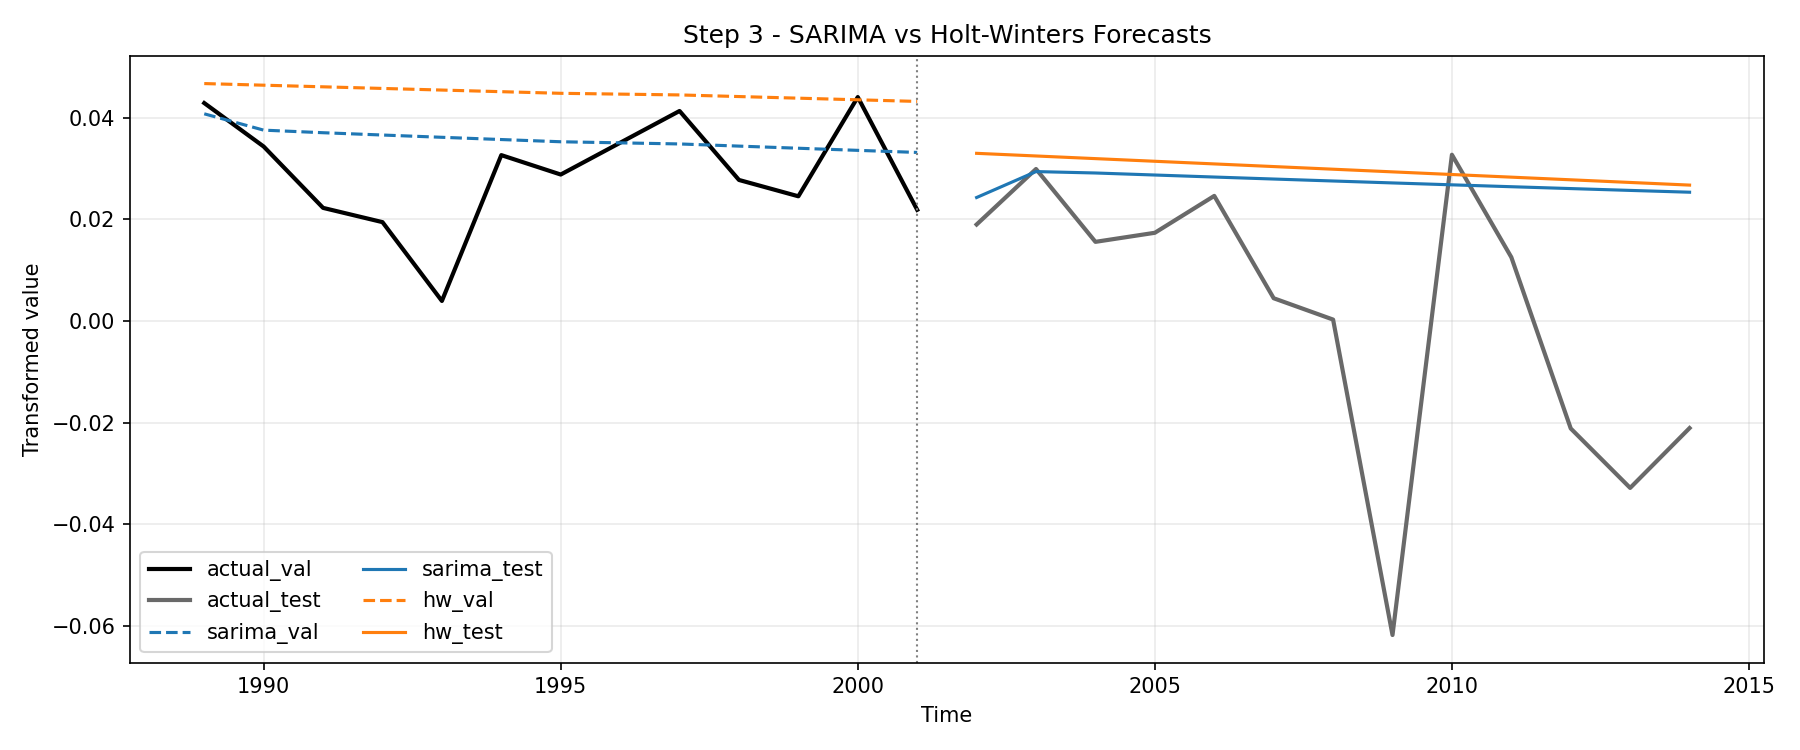

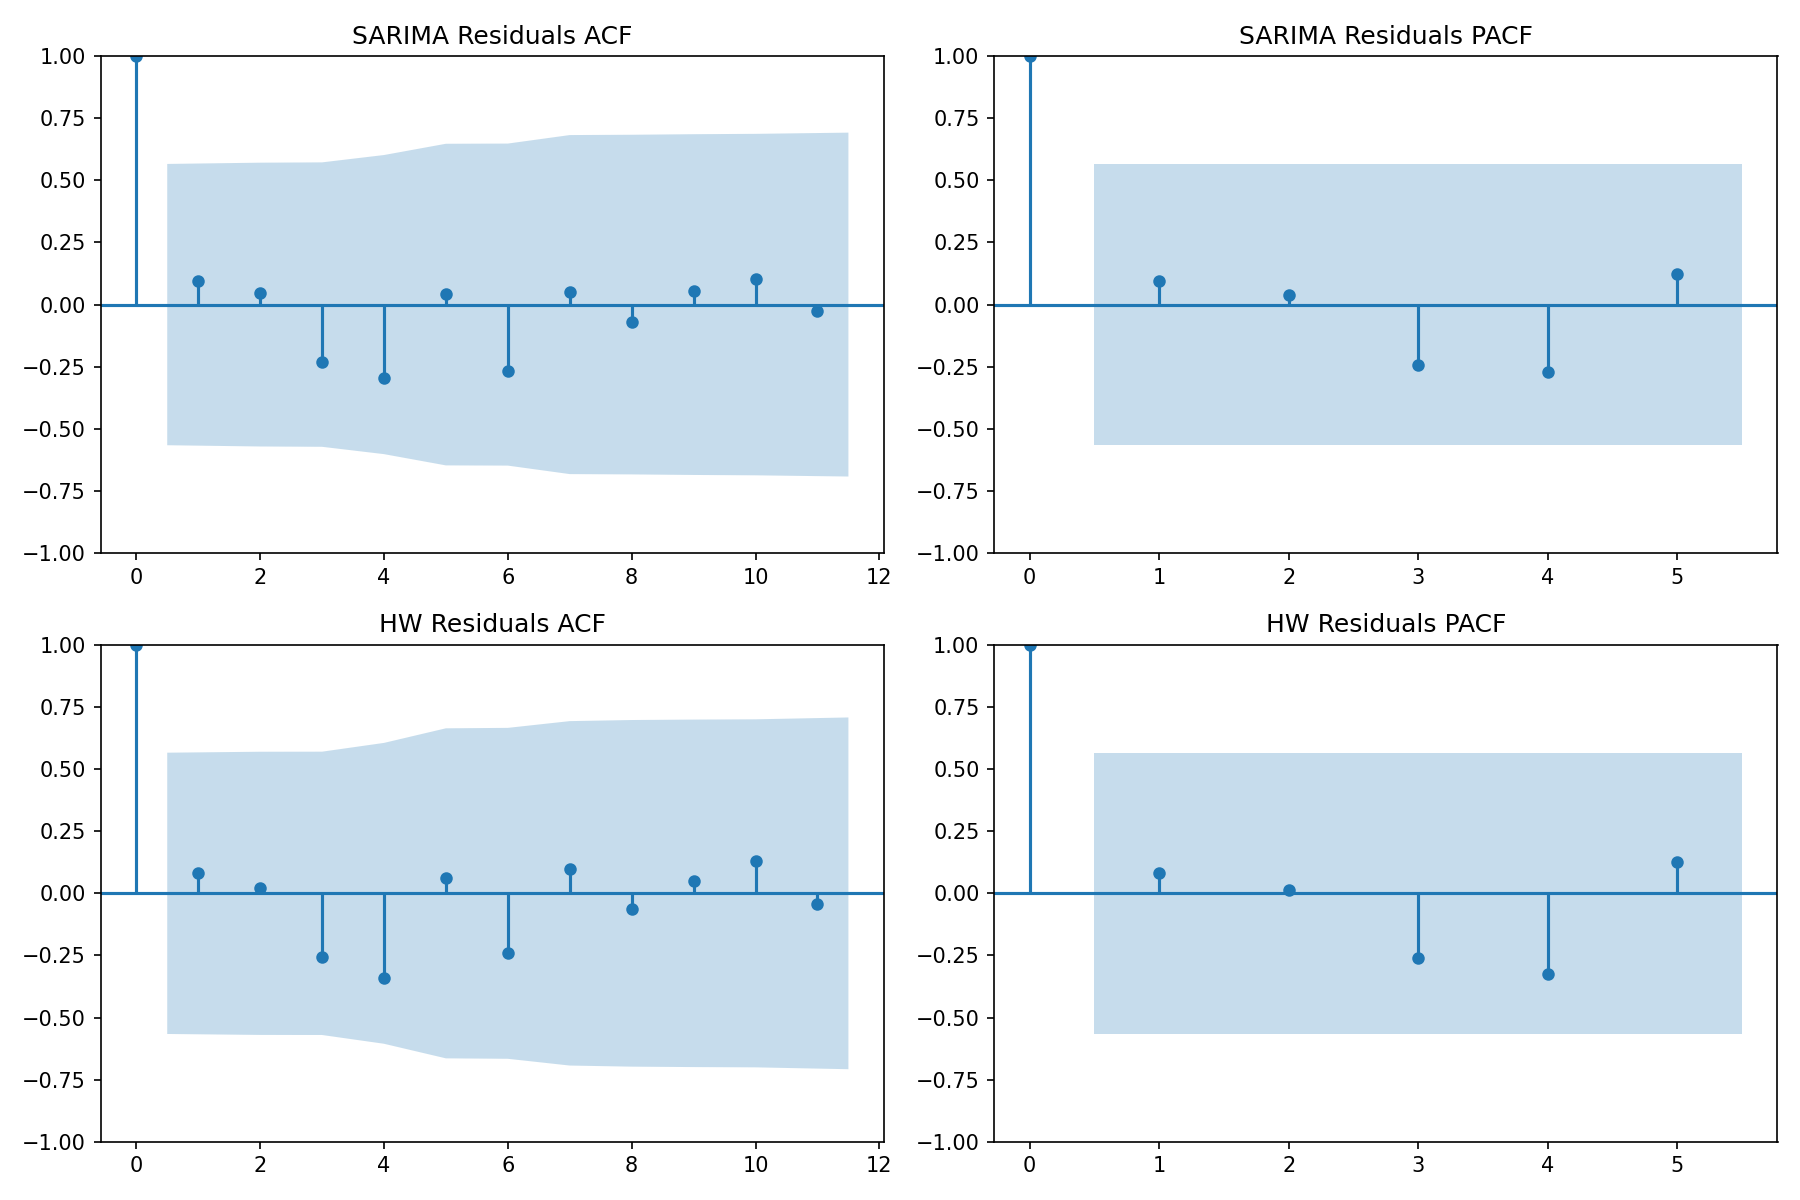

In [24]:
display(stat_summary_df.sort_values("rmse_test"))
display(stat_residual_diag_df)

display(Image(filename=str(stat_plots_dir / "tavola_1_14_stat_forecast_comparison_v1.png")))
display(Image(filename=str(stat_plots_dir / "tavola_1_14_stat_residuals_diagnostics_v1.png")))

### 3.4 Conclusione

Il modello statistico finale viene scelto in base alla **generalizzazione su test** (RMSE principale, MAE come supporto).
L'altro modello resta benchmark ufficiale per il confronto con i rami ML e Neural.

In [25]:
winner_row = stat_summary_df.sort_values(["rmse_test", "mae_test"], ascending=[True, True]).iloc[0]
winner_name = winner_row["model"]

print(f"Winner Step 3: {winner_name}")
print(f"Best params: {winner_row['best_params']}")
print(f"Test RMSE: {winner_row['rmse_test']:.6f}")
print(f"Test MAE: {winner_row['mae_test']:.6f}")
print(f"Test MAPE: {winner_row['mape_test']:.4f}%")

display(stat_winner_params.to_frame("value"))

Winner Step 3: sarima
Best params: {'order': (2, 0, 2), 'seasonal_order': (0, 0, 0, 0)}
Test RMSE: 0.036796
Test MAE: 0.026623
Test MAPE: 921.0375%


,value
model,sarima
best_params,"{'order': (2, 0, 2), 'seasonal_order': (0, 0, ..."
rmse_val,0.013002
mae_val,0.010281
mape_val,97.815859
mbe_val,0.0071
abs_mbe_val,0.0071
rmse_val_orig,16675.810025
mae_val_orig,14295.104546
mape_val_orig,5.589321


### 3.5 Predizioni in scala originale

La logica di inversione (log1p + diff1 -> scala originale) è ora parte del modulo statistico (`sarima_hw.py`) ed è eseguita durante la pipeline in `main.py`.

Qui visualizziamo direttamente il grafico salvato negli artifact di Step 3, così la sezione notebook resta coerente con la logica applicativa.

Original-scale plot: c:\Users\giann\Documents\GitHub\FinalProject\Results\plots\forecasting\tavola_1_14_stat_forecast_original_scale_v1.png


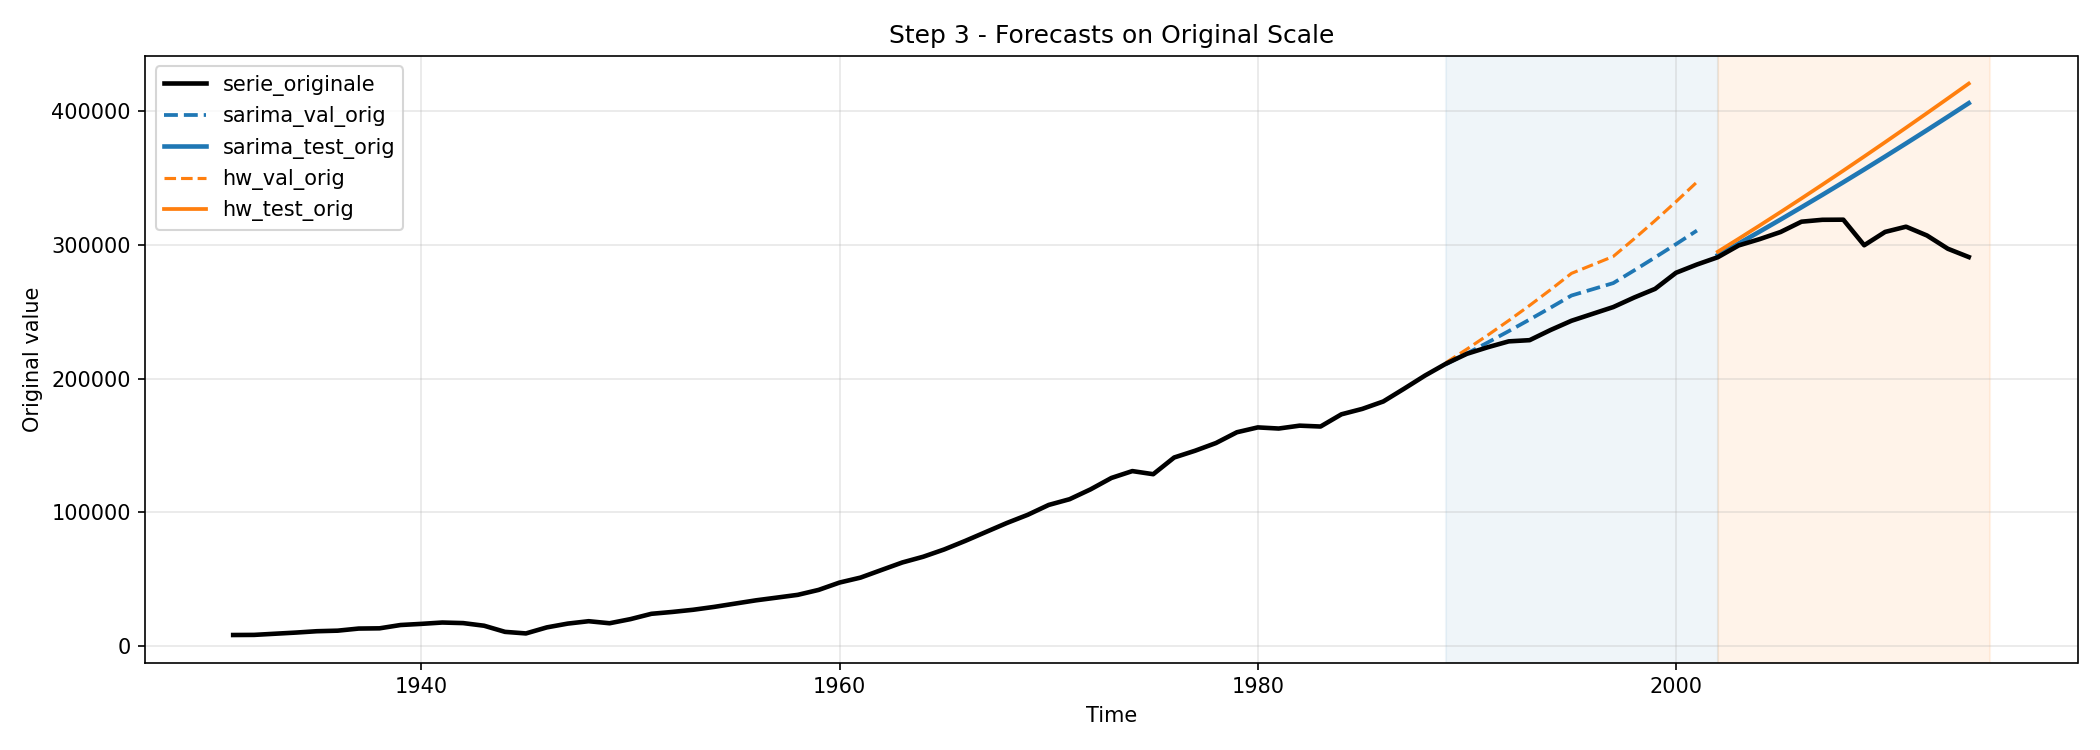

In [26]:
from pathlib import Path
from IPython.display import Image, display

orig_plot_path = stat_plots_dir / "tavola_1_14_stat_forecast_original_scale_v1.png"

print(f"Original-scale plot: {orig_plot_path}")
if Path(orig_plot_path).exists():
    display(Image(filename=str(orig_plot_path)))
else:
    print("Plot non trovato. Esegui main.py per rigenerare gli artifact di Step 3.")

# 4 Modelli ML non neurali

In questa sezione carichiamo gli artifact ML non-neurali rigenerati sui consumi e mostriamo:

- baseline (v1, senza XGBoost);
- esteso (v2, con XGBoost);
- confronto finale con ranking su RMSE test in scala originale.

In [27]:
import json

ml_metrics_dir = project_root / "Results" / "metrics"
ml_plots_dir = project_root / "Results" / "plots" / "forecasting"
ml_artifacts_dir = project_root / "Results" / "artifacts"

ml_summary_v1 = pd.read_csv(ml_metrics_dir / "tavola_1_14_ml_summary_v1.csv")
ml_grid_v1 = pd.read_csv(ml_metrics_dir / "tavola_1_14_ml_grid_v1.csv")
ml_summary_v2 = pd.read_csv(ml_metrics_dir / "tavola_1_14_ml_summary_xgb_v2.csv")
ml_grid_v2 = pd.read_csv(ml_metrics_dir / "tavola_1_14_ml_grid_xgb_v2.csv")
ml_compare_all = pd.read_csv(ml_metrics_dir / "tavola_1_14_comparison_all_models.csv")

with open(ml_artifacts_dir / "tavola_1_14_ml_winner_params_v1.json", "r", encoding="utf-8") as f:
    ml_winner_v1 = pd.Series(json.load(f))
with open(ml_artifacts_dir / "tavola_1_14_ml_winner_params_xgb_v2.json", "r", encoding="utf-8") as f:
    ml_winner_v2 = pd.Series(json.load(f))

print(f"Step 4 baseline rows: {len(ml_summary_v1)}")
print(f"Step 4 extended rows: {len(ml_summary_v2)}")

Step 4 baseline rows: 3
Step 4 extended rows: 4


In [28]:
display(ml_compare_all.sort_values("RMSE_test(GWh)").head(10))

best_global = ml_compare_all.loc[ml_compare_all["RMSE_test(GWh)"].idxmin()]
print("Best global model (Step 3 + Step 4):")
print(f"model={best_global['model']}")
print(f"experiment={best_global['experiment']}")
print(f"RMSE_test(GWh)={best_global['RMSE_test(GWh)']:.1f}")

,experiment,model,lookback,RMSE_val(GWh),MAE_val(GWh),MAPE_val(%),|MBE|_val(GWh),RMSE_test(GWh),MAE_test(GWh),MAPE_test(%),|MBE|_test(GWh)
2,step4_baseline (no XGBoost),decision_tree,12,3516.6,3177.0,1.3,2135.0,55379.3,40939.4,13.5,40939.4
0,step3_statistical,sarima,-,16675.8,14295.1,5.6,14220.7,56063.0,41806.9,13.8,41806.9
3,step4_extended (XGBoost on),gradient_boosting,6,1388.5,1138.8,0.5,639.4,57364.6,42776.5,14.1,42776.5
4,step4_baseline (no XGBoost),gradient_boosting,6,2589.6,2300.8,0.9,2191.7,59171.7,43663.8,14.4,43663.8
5,step4_extended (XGBoost on),decision_tree,12,2965.4,2584.6,1.1,465.6,59976.7,44965.2,14.8,44965.2
6,step4_extended (XGBoost on),xgboost,12,2258.0,1740.9,0.7,1713.8,64083.7,48459.2,16.0,48459.2
1,step3_statistical,holt_winters,-,36272.1,30692.2,11.9,30692.2,65024.5,50452.7,16.6,50452.7
7,step4_extended (XGBoost on),random_forest,12,1599.3,1196.9,0.5,1089.9,66041.7,50383.5,16.6,50383.5
8,step4_baseline (no XGBoost),random_forest,12,2283.4,1866.6,0.7,1480.8,67253.4,51176.9,16.9,51176.9


Best global model (Step 3 + Step 4):
model=decision_tree
experiment=step4_baseline (no XGBoost)
RMSE_test(GWh)=55379.3


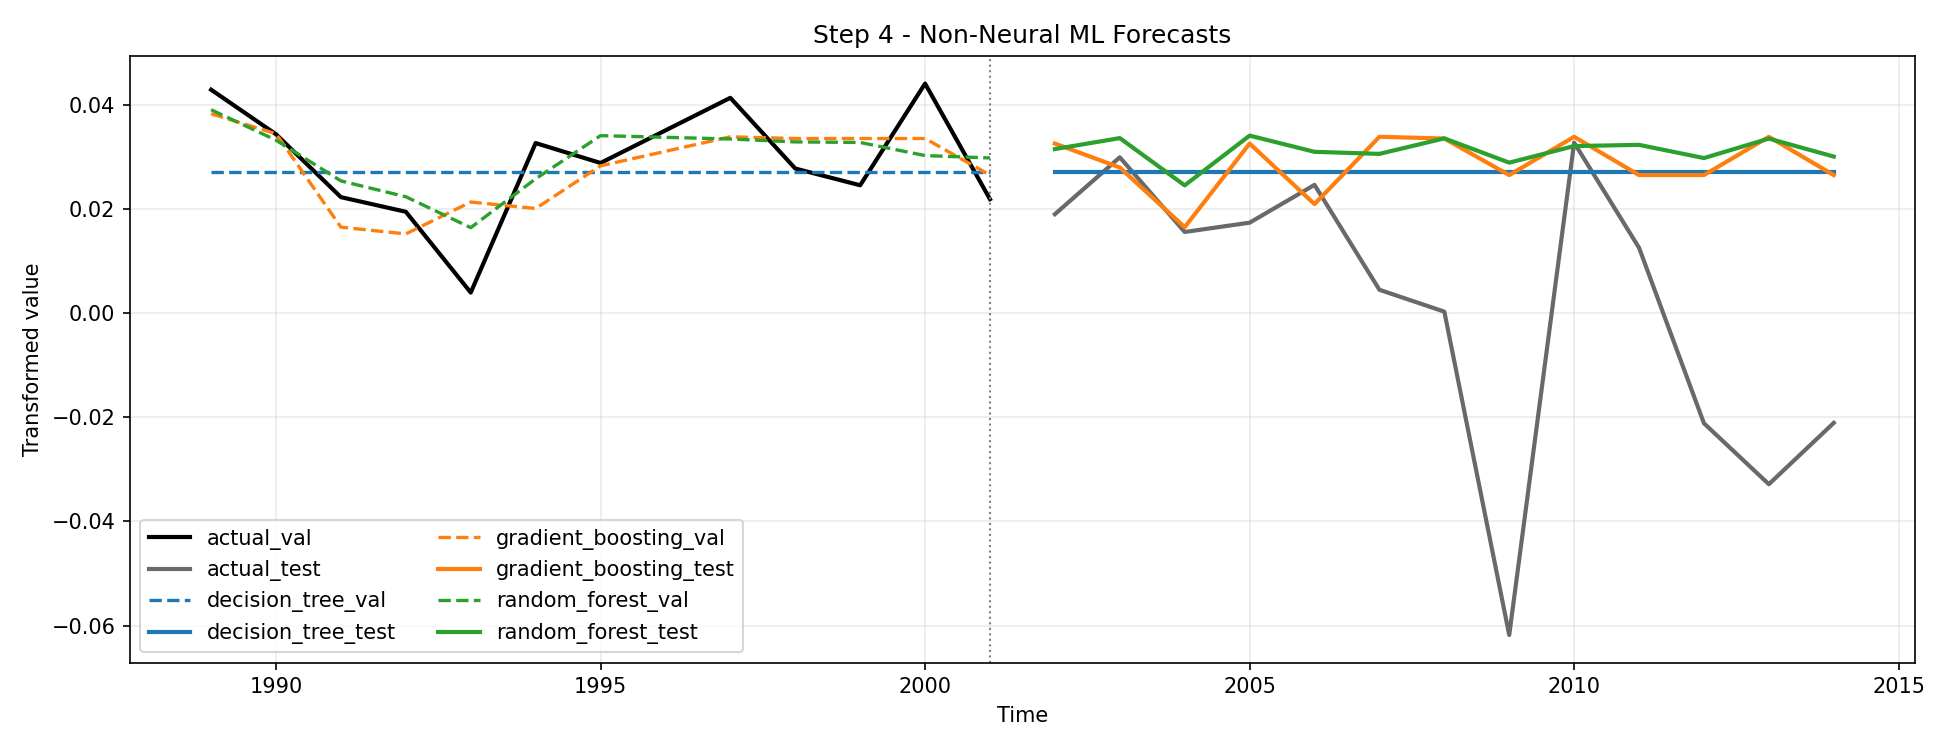

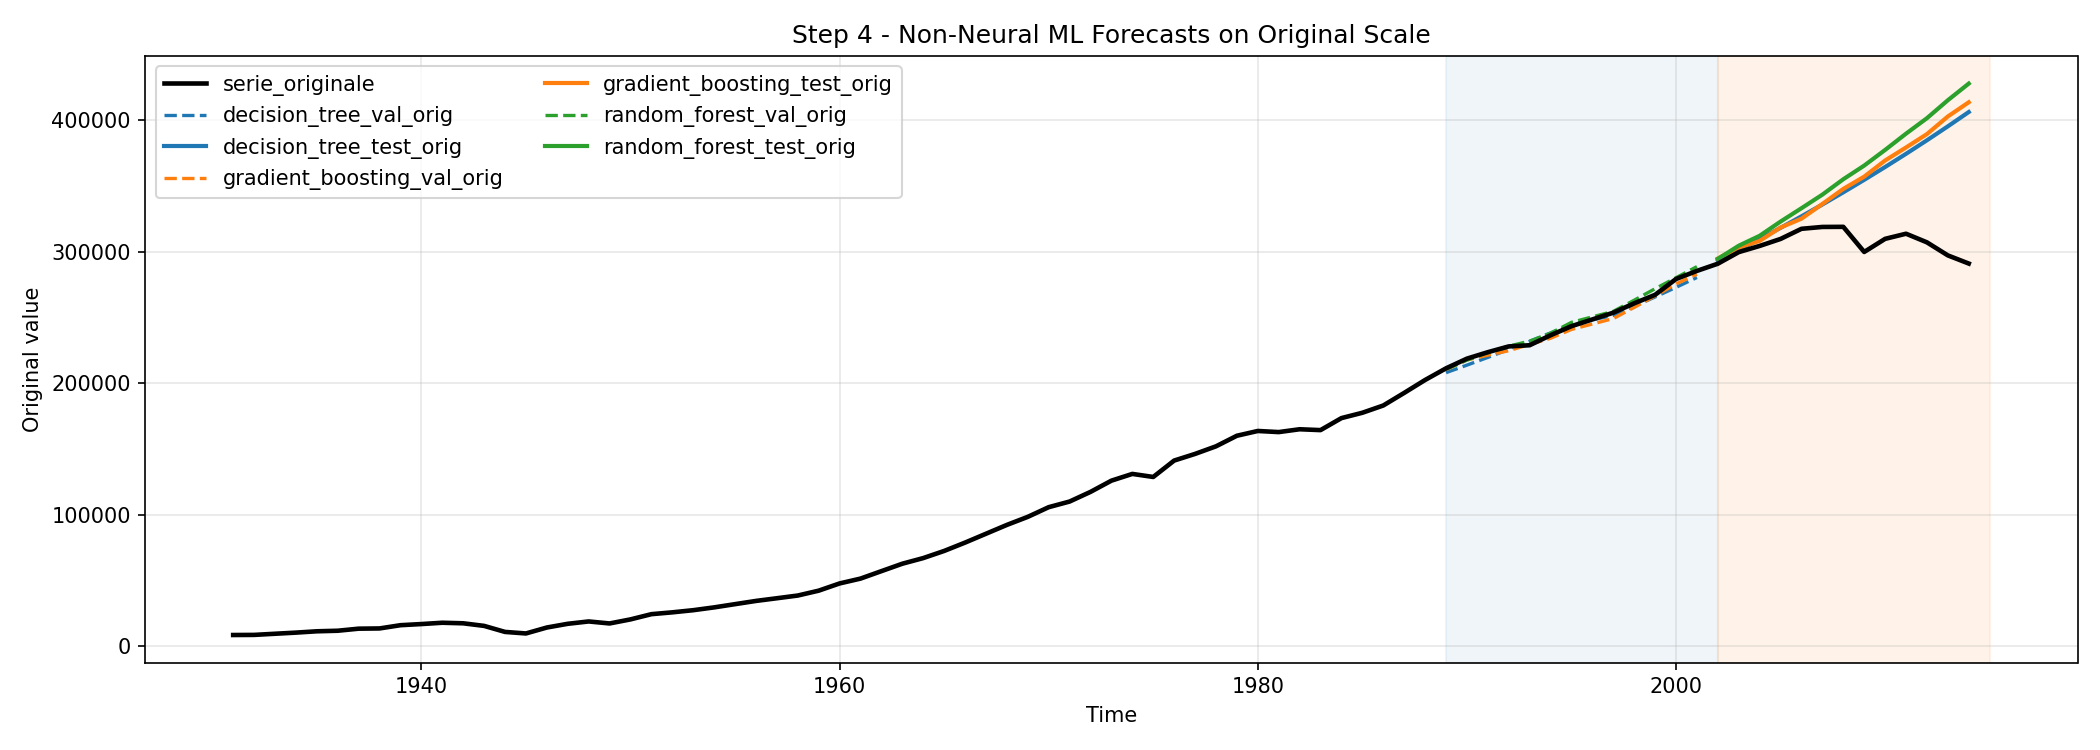

Extended comparison plot not found: tavola_1_14_ml_forecast_comparison_xgb_v2.png
Extended original-scale plot not found: tavola_1_14_ml_forecast_original_scale_xgb_v2.png


In [30]:
from pathlib import Path

base_cmp = ml_plots_dir / "tavola_1_14_ml_forecast_comparison_v1.png"
base_orig = ml_plots_dir / "tavola_1_14_ml_forecast_original_scale_v1.png"
xgb_cmp = ml_plots_dir / "tavola_1_14_ml_forecast_comparison_xgb_v2.png"
xgb_orig = ml_plots_dir / "tavola_1_14_ml_forecast_original_scale_xgb_v2.png"

if Path(base_cmp).exists():
    display(Image(filename=str(base_cmp)))
if Path(base_orig).exists():
    display(Image(filename=str(base_orig)))

if Path(xgb_cmp).exists():
    display(Image(filename=str(xgb_cmp)))
else:
    print("Extended comparison plot not found: tavola_1_14_ml_forecast_comparison_xgb_v2.png")

if Path(xgb_orig).exists():
    display(Image(filename=str(xgb_orig)))
else:
    print("Extended original-scale plot not found: tavola_1_14_ml_forecast_original_scale_xgb_v2.png")

In [31]:
display(ml_summary_v1.sort_values("rmse_test_orig"))
display(ml_summary_v2.sort_values("rmse_test_orig"))

print("Winner params baseline (v1):")
display(ml_winner_v1.to_frame("value"))

print("Winner params extended (v2):")
display(ml_winner_v2.to_frame("value"))

,model,lookback,feature_selection,selected_features,n_selected_features,best_params,rmse_val,mae_val,mape_val,mbe_val,...,mape_test,mbe_test,abs_mbe_test,rmse_test_orig,mae_test_orig,mape_test_orig,mbe_test_orig,abs_mbe_test_orig,rank_rmse_test,rank_abs_mbe_test
0,decision_tree,12,importance,"lag_1, lag_2, lag_3, lag_4, lag_5, lag_6",6,"{'max_depth': 3, 'min_samples_leaf': 1, 'rando...",0.011085,0.008782,70.218273,-0.001475,...,910.541477,0.025674,0.025674,55379.298932,40939.363135,13.513781,40939.363135,40939.363135,55379.298932,40939.363135
1,gradient_boosting,6,importance,"lag_1, lag_2, lag_3, lag_4, lag_6, lag_5",6,"{'n_estimators': 300, 'learning_rate': 0.05, '...",0.008342,0.006885,55.163464,-0.000743,...,1105.979379,0.027069,0.027069,59171.732195,43663.779750,14.416695,43663.779750,43663.779750,59171.732195,43663.779750
2,random_forest,12,importance,"lag_1, lag_2, lag_3, lag_4, lag_5, lag_6",6,"{'n_estimators': 200, 'max_depth': 6, 'min_sam...",0.007492,0.006543,44.657852,0.000948,...,1112.835307,0.029669,0.029669,67253.400148,51176.851463,16.870713,51176.851463,51176.851463,67253.400148,51176.851463


,model,lookback,feature_selection,selected_features,n_selected_features,best_params,rmse_val,mae_val,mape_val,mbe_val,...,mape_test,mbe_test,abs_mbe_test,rmse_test_orig,mae_test_orig,mape_test_orig,mbe_test_orig,abs_mbe_test_orig,rank_rmse_test,rank_abs_mbe_test
0,gradient_boosting,6,importance,"lag_1, lag_2, lag_3, lag_4, lag_6, lag_5",6,"{'n_estimators': 400, 'learning_rate': 0.05, '...",0.007012,0.005756,47.935422,0.000124,...,1138.886262,0.026101,0.026101,57364.571306,42776.544089,14.116597,42776.544089,42776.544089,57364.571306,42776.544089
1,decision_tree,12,importance,"lag_1, lag_2, lag_3, lag_4, lag_5, lag_6",6,"{'max_depth': 5, 'min_samples_leaf': 2, 'rando...",0.010987,0.008687,73.888441,0.000085,...,963.286229,0.027235,0.027235,59976.738201,44965.219001,14.833150,44965.219001,44965.219001,59976.738201,44965.219001
2,xgboost,12,importance,"lag_1, lag_2, lag_3, lag_4, lag_5, lag_6",6,"{'n_estimators': 300, 'learning_rate': 0.03, '...",0.007535,0.005908,39.003001,-0.000928,...,1095.476017,0.028739,0.028739,64083.657077,48459.247496,15.984942,48459.247496,48459.247496,64083.657077,48459.247496
3,random_forest,12,importance,"lag_1, lag_2, lag_3, lag_4, lag_5, lag_6",6,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.006074,0.005253,32.706757,0.000741,...,1123.128527,0.029161,0.029161,66041.695452,50383.457825,16.609237,50383.457825,50383.457825,66041.695452,50383.457825


Winner params baseline (v1):


,value
model,decision_tree
lookback,12
feature_selection,importance
selected_features,"lag_1, lag_2, lag_3, lag_4, lag_5, lag_6"
n_selected_features,6
best_params,"{'max_depth': 3, 'min_samples_leaf': 1, 'rando..."
rmse_val,0.011085
mae_val,0.008782
mape_val,70.218273
mbe_val,-0.001475


Winner params extended (v2):


,value
model,gradient_boosting
lookback,6
feature_selection,importance
selected_features,"lag_1, lag_2, lag_3, lag_4, lag_6, lag_5"
n_selected_features,6
best_params,"{'n_estimators': 400, 'learning_rate': 0.05, '..."
rmse_val,0.007012
mae_val,0.005756
mape_val,47.935422
mbe_val,0.000124
